# Baseline 5 HOWTO — 피처 중요도 분석 기반 모델 개선

`baseline_5.ipynb`의 전처리 파이프라인을 그대로 이어받아, **어떤 기상 피처가 실제로 발전량을 설명하는지**를
트리 기반 모델과 SHAP으로 분석하고, 선별한 피처만으로 재학습해 baseline 5 대비 성능 변화를 정량 비교한다.

| Step | 내용 |
|------|------|
| 0 | 환경 설정 — 라이브러리·경로·한글 폰트 |
| 1 | 전처리 완료본 생성 및 로드 (`Windforce/Preprocessing/` 활용 → `prep/`) |
| 2 | 트리 기반 모델(LightGBM) 학습 + Feature Importance 시각화 |
| 3 | SHAP Summary Plot — 기여도·방향성·비선형 관계 분석 |
| 4 | 피처 셀렉션 — 노이즈 기준 + 상관 중복 제거 + 누적 기여도 |
| 5 | 재학습 및 baseline 5 대비 성능 비교 |
| 6 | 제출 CSV 생성 (선택) |

---

## ⚠️ baseline 5에서 발견한 치명적 버그 — IDW 가중치 전부 0

`compute_group_weight()`는 `turbine_meta["group"]`을 **`"kpx_group_1"` 문자열**과 비교한다.

```python
for j, group in enumerate(KPX_GROUPS):        # KPX_GROUPS = ("kpx_group_1", ...)
    selected = (meta["group"] == group).to_numpy()
```

그런데 baseline 3~5는 `kpx_info`의 `KPX그룹` 컬럼(**정수 1/2/3**)을 그대로 `group`으로 넘긴다.
따라서 `selected`가 전부 `False`가 되어 **가중치 행렬이 전부 0**이 되고,
`transformToGroupIDW()`가 만든 LDAPS·GFS 그룹 피처가 **모두 정확히 0.0**이 된다.

> 즉 baseline 3~5의 SVR·LSTM은 **정보가 하나도 없는 0 행렬**을 입력으로 학습했다.
> `improvement.md`가 지목한 손실함수 문제(A)보다 이쪽이 더 근본적인 원인이다.

이 노트북 Step 1에서 `group` 키를 `"kpx_group_{N}"` 문자열로 바꿔 수정한다.

---
## Step 0. 환경 설정

In [1]:
# LightGBM / SHAP 미설치 환경에서만 아래 주석을 해제해 1회 실행한다.
# %pip install lightgbm shap
# 설치 후 커널을 재시작해야 numpy 버전 변경이 반영된다.

In [2]:
import os
import sys
import time
import warnings

import re
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import plotly.express as px
# 기본 데이터 분석·시각화 라이브러리

from sklearn.preprocessing import MinMaxScaler
# 스케일링은 반드시 학습 구간에만 fit한다

warnings.filterwarnings("ignore")
# LightGBM/SHAP의 버전 경고가 출력을 가리지 않도록 억제

In [3]:
import lightgbm as lgb
# 트리 기반 회귀 모델. 정형 피처에서 LSTM보다 안정적으로 수렴한다
import shap
# SHAP: 예측값에 대한 피처별 기여도를 게임이론(Shapley value)으로 분해

print(f"lightgbm {lgb.__version__} / shap {shap.__version__}")
# 두 라이브러리가 모두 import되면 Step 2~4를 그대로 실행할 수 있다

lightgbm 4.7.0 / shap 0.52.0


In [4]:
ROOT: str = next(
    (p for p in ["d:/workspaces/WINDFORCE", "D:/workspaces/WINDFORCE", "/Users/ksydata/WINDFORCE"]
     if os.path.exists(p)),
    os.getcwd(),
)
# 실행 환경(Windows/macOS)에 따라 프로젝트 루트를 자동 선택한다
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
# Windforce 패키지 탐색 경로를 sys.path에 추가
print(f"ROOT: {ROOT}")

from Windforce import (
    WindforceDataLoader,
    LDAPSFeatureEngineer,
    GFSFeatureEngineer,
    EvaluationMetrics,
    RATED_CAPACITY_KW,
    TIME_STEP_HOURS,
)
# Windforce 루트 패키지에서 데이터 로더·전처리기·평가지표 import

from Windforce.Modeling import (
    BaselineModels,
    WindforceDatasetBuilder,
)
# Modeling 서브패키지에서 베이스라인 모델과 데이터셋 빌더 import

ROOT: d:/workspaces/WINDFORCE


In [5]:
pd.set_option("display.max_columns", None)
# 열 생략 없이 모든 컬럼 표시
pd.options.display.float_format = "{:,.6f}".format
# 지수 표기(e) 대신 실수 6자리 고정 소수점으로 출력

GROUPS  = [1, 2, 3]
# KPX 평가 그룹 번호 목록
SEED    = 42
# 재현성 확보를 위한 난수 시드
TEST_RATIO = 0.2
# 시간순 마지막 20%를 검증(hold-out) 구간으로 사용 (baseline 5와 동일 조건)
CORR_THRESHOLD = 0.95
# 이 값을 넘는 상관을 가진 피처 쌍은 중복으로 보고 하나만 남긴다
NOISE_FEATURE_COUNT = 3
# 피처 선별 기준선으로 삽입할 무작위 노이즈 피처 개수
CUMULATIVE_RATIO = 1.0
# 누적 SHAP 기여도 상위 몇 %까지 유지할지. 1.0이면 꼬리 절단을 하지 않는다
# (0.99 / 0.995 / 0.999 / 1.0을 실측 비교한 결과 1.0이 가장 좋았다 — Step 4 표 참조)

PREP_DIR = f"{ROOT}/prep"
# 전처리 완료본(.csv.gz)을 저장·재사용할 폴더
os.makedirs(PREP_DIR, exist_ok=True)

np.random.seed(SEED)
# 재현성 확보를 위해 난수 시드 고정

matplotlib 폰트: Malgun Gothic


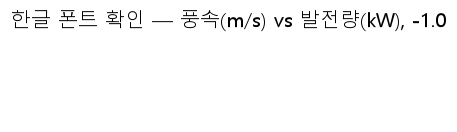

In [6]:
def setPlotStyle(base_font_size: int = 11) -> str:
    """한글·영문 폰트 깨짐과 마이너스 기호 깨짐을 막는 matplotlib 기본 스타일 설정 함수

    Returns:
        - 실제로 선택된 폰트 이름

    Logic:
        - OS별로 존재하는 한글 폰트를 순서대로 탐색해 가장 먼저 발견된 것을 사용한다
          (Windows: Malgun Gothic / macOS: AppleGothic / Linux: NanumGothic)
        - axes.unicode_minus = False : 한글 폰트에 마이너스 글리프가 없어 □로 깨지는 현상 방지
        - 영문 축 라벨도 같은 폰트로 렌더링되므로 혼용 시에도 글꼴이 튀지 않는다
    """
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR",
                  "Nanum Gothic", "Gulim", "DejaVu Sans"]
    # 한글 지원 폰트 후보 (앞에서부터 우선 적용)
    installed = {f.name for f in font_manager.fontManager.ttflist}
    # 현재 환경에 설치된 폰트 이름 집합
    selected = next((f for f in candidates if f in installed), "DejaVu Sans")
    # 후보 중 설치된 첫 번째 폰트 선택. 하나도 없으면 matplotlib 기본 폰트로 대체

    plt.rcParams["font.family"] = selected
    plt.rcParams["axes.unicode_minus"] = False
    # 마이너스 기호가 네모(□)로 깨지는 현상 방지
    plt.rcParams["font.size"] = base_font_size
    plt.rcParams["figure.dpi"] = 110
    plt.rcParams["savefig.bbox"] = "tight"
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.3
    # 격자를 옅게 깔아 막대·산점도 값 비교를 쉽게 한다
    return selected


PLOT_FONT = setPlotStyle()
print(f"matplotlib 폰트: {PLOT_FONT}")

import plotly.io as pio
pio.templates.default = "plotly_white"
# plotly도 동일한 밝은 배경 테마로 통일
pio.templates["plotly_white"].layout.font.family = PLOT_FONT
# plotly 그래프의 한글 라벨도 같은 폰트로 렌더링

plt.figure(figsize=(4, 1))
plt.title("한글 폰트 확인 — 풍속(m/s) vs 발전량(kW), -1.0")
plt.axis("off")
plt.show()
# 제목의 한글과 마이너스 기호가 정상 출력되면 설정 완료

---
## Step 1. 전처리 완료본 생성 및 로드

`Windforce/Preprocessing/`의 `LDAPSFeatureEngineer` · `GFSFeatureEngineer`로
격자 예보를 KPX 그룹 단위 피처로 변환한 뒤, `prep/` 폴더에 **전처리 완료본**을 저장한다.

```
TRAIN/ldaps_train.csv (16격자)     TRAIN/gfs_train.csv (9격자)
        ↓ transformLDAPS()                 ↓ transformGFS()
   격자별 물리 파생변수                격자별 다층 바람·전단·밀도
        ↓ transformToGroupIDW(turbine_meta)  ← 🔧 group 키 문자열 수정 지점
   그룹 × 시각 공간가중 예보표
        ↓ transformForecastFeature()         ← baseline 5가 쓰지 않던 램프·변화량 8종 추가
        ↓ WindforceDatasetBuilder.build(g)
   prep/dataset_train_group{g}.csv.gz  (피처 127개 + 타깃)
   prep/dataset_test_group{g}.csv.gz   (피처 127개)
```

한 번 만들어 두면 이후 실행에서는 `.csv.gz`만 읽으므로 전처리를 다시 돌리지 않는다.

In [7]:
def parseDMS(coord_str: str) -> tuple[float, float]:
    """도분초(DMS) 형식 문자열을 십진수(DD) 위도·경도로 변환하는 함수

    Args:
        - coord_str: '37°16\'55.61"N 128°57\'02.10"E' 형태의 문자열

    Returns:
        - (위도, 경도) 십진수 튜플
    """
    tokens = re.findall(r"[\d.]+|[NSEW]", coord_str.replace('""', '"'))
    # 숫자 토큰과 방향(N/S/E/W) 분리
    lat = float(tokens[0]) + float(tokens[1]) / 60 + float(tokens[2]) / 3600
    lon = float(tokens[4]) + float(tokens[5]) / 60 + float(tokens[6]) / 3600
    # 도 + 분/60 + 초/3600 으로 십진도 환산
    if tokens[3] == "S":
        lat = -lat
    if tokens[7] == "W":
        lon = -lon
    # 남반구(S)·서경(W)은 음수로 변환 (국내 데이터라 실제로는 발동하지 않는다)
    return lat, lon


def buildTurbineMeta(kpx_info: pd.DataFrame) -> pd.DataFrame:
    """kpx_info를 IDW 공간집계용 turbine_meta로 변환하는 함수

    Args:
        - kpx_info: 터빈 1기 = 1행인 KPX 메타 표

    Returns:
        - group / lat / lon / cap_kw 컬럼을 가진 DataFrame

    Logic:
        - 🔧 buga fix: compute_group_weight()는 group을 "kpx_group_1" 문자열과 비교한다.
          baseline 3~5처럼 정수 1/2/3을 넘기면 매칭이 전부 실패해 가중치가 0 행렬이 되고,
          IDW 집계 결과가 통째로 0.0이 된다. 반드시 문자열 키로 맞춰야 한다.
    """
    kpx = kpx_info.copy()
    # 원본 DataFrame 변형 방지

    coords = kpx["좌표(Google)"].apply(parseDMS)
    kpx["lat"] = coords.apply(lambda x: x[0])
    kpx["lon"] = coords.apply(lambda x: x[1])
    # DMS 좌표 문자열을 십진 위도·경도 컬럼으로 분리

    meta = kpx[["KPX그룹", "lat", "lon", "설비용량(MW)"]].rename(
        columns={"KPX그룹": "group", "설비용량(MW)": "cap_kw"}
    ).copy()
    meta["cap_kw"] = meta["cap_kw"] * 1000.0
    # MW → kW 단위 변환

    meta["group"] = "kpx_group_" + meta["group"].astype(int).astype(str)
    # 🔧 핵심 수정: 정수 그룹 번호를 KPX_GROUPS와 같은 문자열 키로 변환

    return meta.reset_index(drop=True)

In [8]:
class PreprocessedDatasetBuilder:
    """LDAPS·GFS 원본을 그룹별 학습/평가 테이블로 변환해 prep/에 저장·재사용하는 클래스

    사용 순서:
        builder = PreprocessedDatasetBuilder(loader, prep_dir = PREP_DIR)
        builder.buildAll()                 # 캐시가 없으면 전처리 후 저장
        train_df = builder.load(1, "train")  # 캐시 로드
    """

    def __init__(self, loader: WindforceDataLoader, prep_dir: str, groups: list = GROUPS):
        self.loader = loader
        # 원본 CSV 접근용 데이터 로더
        self.prep_dir = prep_dir
        # 전처리 완료본 저장 폴더
        self.groups = groups
        self.turbine_meta: Optional[pd.DataFrame] = None
        # buildAll() 실행 시 채워지는 터빈 메타 (group/lat/lon/cap_kw)

    def _path(self, group: int, split: str) -> str:
        """그룹·split별 캐시 파일 경로를 만드는 내부 헬퍼 메서드"""
        return f"{self.prep_dir}/dataset_{split}_group{group}.csv.gz"
        # gzip CSV로 저장해 용량을 1/5 수준으로 줄인다 (pyarrow 의존성 없이 동작)

    def isCached(self) -> bool:
        """모든 그룹·split의 캐시 파일이 존재하는지 확인하는 메서드"""
        return all(
            os.path.exists(self._path(g, s))
            for g in self.groups for s in ("train", "test")
        )

    def _transformSplit(self, ldaps_key: str, gfs_key: str) -> tuple[pd.DataFrame, pd.DataFrame]:
        """LDAPS·GFS 원본 한 쌍을 그룹 단위 피처표로 변환하는 내부 헬퍼 메서드

        Logic:
            - transformLDAPS/transformGFS : 격자별 물리 파생변수 + 품질 플래그
            - transformToGroupIDW         : 격자 → KPX 그룹 역거리가중 집계
            - transformForecastFeature    : 램프·변화량 8종 (baseline 5는 호출하지 않았다)
        """
        ldaps_fe = LDAPSFeatureEngineer()
        gfs_fe = GFSFeatureEngineer()
        # 그룹 지정 없이 생성 → 전체 격자를 처리한 뒤 IDW로 3그룹에 매핑

        ldaps_grid = ldaps_fe.transformLDAPS(self.loader[ldaps_key])
        ldaps_group = ldaps_fe.transformToGroupIDW(ldaps_grid, self.turbine_meta)
        ldaps_group = ldaps_fe.transformForecastFeature(ldaps_group)
        print(f"  LDAPS: 격자 {ldaps_grid.shape} → 그룹 {ldaps_group.shape}")

        gfs_grid = gfs_fe.transformGFS(self.loader[gfs_key])
        gfs_group = gfs_fe.transformToGroupIDW(gfs_grid, self.turbine_meta)
        gfs_group = gfs_fe.transformForecastFeature(gfs_group)
        print(f"  GFS  : 격자 {gfs_grid.shape} → 그룹 {gfs_group.shape}")

        return ldaps_group, gfs_group

    def buildAll(self, force: bool = False) -> None:
        """전체 그룹의 학습·평가 테이블을 생성해 prep/에 저장하는 메서드

        Args:
            - force: True면 캐시가 있어도 전처리를 다시 실행한다
        """
        if self.isCached() and not force:
            print("✅ 전처리 완료본이 이미 존재합니다. load()로 바로 사용하세요.")
            return
            # 캐시가 있으면 재전처리를 건너뛴다 (약 1분 절약)

        started = time.time()
        self.turbine_meta = buildTurbineMeta(self.loader["kpx_info"])
        print(f"turbine_meta: {self.turbine_meta.shape}, group 키 = {sorted(self.turbine_meta['group'].unique())}")

        print("\n[train] 격자 전처리 + IDW 그룹 집계 중...")
        ldaps_train, gfs_train = self._transformSplit("ldaps_train", "gfs_train")
        print("\n[test] 격자 전처리 + IDW 그룹 집계 중...")
        ldaps_test, gfs_test = self._transformSplit("ldaps_test", "gfs_test")

        zero_cols = [
            c for c in ldaps_train.select_dtypes(include="number").columns
            if float(ldaps_train[c].abs().max()) == 0.0
        ]
        if zero_cols:
            raise ValueError(f"IDW 집계 결과가 전부 0인 컬럼이 있습니다(가중치 버그 재발): {zero_cols[:5]}")
        # 🔧 회귀 방지 가드: group 키가 다시 정수로 돌아가면 여기서 즉시 실패한다

        train_builder = WindforceDatasetBuilder(ldaps_train, gfs_train, self.loader["train_labels"])
        # 학습 구간: 실제 발전량 라벨과 결합

        test_times = pd.to_datetime(pd.Series(ldaps_test["forecast_kst_dtm"].unique()))
        dummy_labels = pd.DataFrame({"kst_dtm": test_times})
        for g in self.groups:
            dummy_labels[f"kpx_group_{g}"] = 0.0
        test_builder = WindforceDatasetBuilder(ldaps_test, gfs_test, dummy_labels)
        # 평가 구간: 라벨이 없으므로 0으로 채운 더미 라벨로 동일한 병합 경로를 재사용한다

        print()
        for g in self.groups:
            for split, builder in (("train", train_builder), ("test", test_builder)):
                table = builder.build(g)
                path = self._path(g, split)
                table.to_csv(path, index=False, encoding="utf-8-sig", compression="gzip")
                print(f"✅ [그룹{g}] {split}: {table.shape} → {os.path.basename(path)}")
        print(f"\n전처리 완료본 생성 소요: {time.time() - started:.1f}초")

    def load(self, group: int, split: str = "train") -> pd.DataFrame:
        """저장된 전처리 완료본을 읽어 시간순으로 정렬해 반환하는 메서드"""
        path = self._path(group, split)
        if not os.path.exists(path):
            raise FileNotFoundError(f"전처리 완료본이 없습니다: {path}. buildAll()을 먼저 실행하세요")
        df = pd.read_csv(path, encoding="utf-8-sig")
        df["forecast_kst_dtm"] = pd.to_datetime(df["forecast_kst_dtm"])
        # 시각 컬럼을 datetime으로 복원 (CSV 왕복에서 문자열로 바뀌므로)
        return df.sort_values("forecast_kst_dtm").reset_index(drop=True)
        # 시계열 분할이 뒤섞이지 않도록 항상 시간순 정렬 상태로 반환

In [9]:
loader = WindforceDataLoader(root=ROOT)
# WindforceDataLoader 인스턴스 생성 (ROOT: 현재 실행 환경의 프로젝트 루트)
loader.check_paths()
# 등록된 모든 파일의 존재 여부를 ✅/❌ 로 출력

✅  ldaps_train: d:/workspaces/WINDFORCE/TRAIN/ldaps_train.csv
✅  gfs_train: d:/workspaces/WINDFORCE/TRAIN/gfs_train.csv
✅  ldaps_test: d:/workspaces/WINDFORCE/TEST/ldaps_test.csv
✅  gfs_test: d:/workspaces/WINDFORCE/TEST/gfs_test.csv
✅  train_labels: d:/workspaces/WINDFORCE/TRAIN/train_labels.csv
✅  scada_vestas_train: d:/workspaces/WINDFORCE/TRAIN/scada_vestas_train.csv
✅  scada_unison_train: d:/workspaces/WINDFORCE/TRAIN/scada_unison_train.csv
✅  sample_submission: d:/workspaces/WINDFORCE/INFO/sample_submission.csv
✅  kpx_info: d:/workspaces/WINDFORCE/TRAIN/kpx_info.csv


{'ldaps_train': True,
 'gfs_train': True,
 'ldaps_test': True,
 'gfs_test': True,
 'train_labels': True,
 'scada_vestas_train': True,
 'scada_unison_train': True,
 'sample_submission': True,
 'kpx_info': True}

In [10]:
prep_builder = PreprocessedDatasetBuilder(loader, prep_dir=PREP_DIR)
# 전처리 완료본 빌더 생성
prep_builder.buildAll()
# 캐시가 없을 때만 전처리를 수행한다 (약 60초). 다시 만들려면 force=True

✅ 전처리 완료본이 이미 존재합니다. load()로 바로 사용하세요.


In [11]:
def featureCols(df: pd.DataFrame) -> list[str]:
    """타깃·시각 식별자를 제외한 순수 피처 컬럼 목록을 반환하는 함수

    Logic:
        - forecast_kst_dtm / kst_dtm : 시각 식별자 → 학습에 넣으면 미래 정보 누수 위험
        - kpx_group_* : 자기 그룹 타깃은 물론 다른 그룹 타깃도 전부 제외 (그룹 간 누수 방지)
    """
    exclude = {"kst_dtm", "forecast_kst_dtm"} | {f"kpx_group_{i}" for i in range(1, 4)}
    return [c for c in df.columns if c not in exclude]


def splitByTime(df: pd.DataFrame, target_col: str, feat_cols: list[str],
                test_ratio: float = TEST_RATIO):
    """시간순으로 학습·검증 세트를 나누는 함수

    Returns:
        - (X_train, X_valid, y_train, y_valid) 튜플

    Logic:
        - 시계열이므로 랜덤 셔플 분할은 절대 금지한다. 앞 80%를 학습, 뒤 20%를 검증에 쓴다
        - baseline 5의 GroupExperimentRunner(testRatio=0.2)와 동일한 조건이라 점수를 직접 비교할 수 있다
    """
    split = int(len(df) * (1 - test_ratio))
    # 앞쪽 (1-test_ratio)를 학습, 뒤쪽 test_ratio를 검증으로 시간순 분할

    X_train = df.loc[: split - 1, feat_cols].reset_index(drop=True)
    X_valid = df.loc[split:, feat_cols].reset_index(drop=True)
    y_train = df.loc[: split - 1, target_col].to_numpy()
    y_valid = df.loc[split:, target_col].to_numpy()
    return X_train, X_valid, y_train, y_valid


datasets = {}
# {그룹번호: (df, feat_cols, X_train, X_valid, y_train, y_valid)} 형태로 그룹별 데이터를 보관
for g in GROUPS:
    df_g = prep_builder.load(g, "train")
    target_col = f"kpx_group_{g}"
    feat_cols = featureCols(df_g)
    X_train, X_valid, y_train, y_valid = splitByTime(df_g, target_col, feat_cols)
    datasets[g] = (df_g, feat_cols, X_train, X_valid, y_train, y_valid)
    print(f"[그룹{g}] 전체 {df_g.shape} | 피처 {len(feat_cols)}개 | "
          f"train {X_train.shape[0]}행 ({df_g['forecast_kst_dtm'].iloc[0].date()} ~) / "
          f"valid {X_valid.shape[0]}행 (~ {df_g['forecast_kst_dtm'].iloc[-1].date()})")

[그룹1] 전체 (26200, 129) | 피처 127개 | train 20960행 (2022-01-01 ~) / valid 5240행 (~ 2025-01-01)


[그룹2] 전체 (26201, 129) | 피처 127개 | train 20960행 (2022-01-01 ~) / valid 5241행 (~ 2025-01-01)


[그룹3] 전체 (17538, 129) | 피처 127개 | train 14030행 (2023-01-01 ~) / valid 3508행 (~ 2025-01-01)


In [12]:
sample_df = datasets[1][0]
# 그룹1 전처리 완료본으로 구조를 확인한다
print("결측치가 있는 피처 수:", int(sample_df[datasets[1][1]].isna().any().sum()))
print("타깃 통계 (kWh):")
print(sample_df["kpx_group_1"].describe())
sample_df.head(3)

결측치가 있는 피처 수: 16
타깃 통계 (kWh):
count   26,200.000000
mean     6,621.981125
std      6,582.443128
min          0.000000
25%        549.600000
50%      4,252.168000
75%     12,206.905000
max     21,275.305000
Name: kpx_group_1, dtype: float64


,u10,v10,ws10,air_density,wind_power_density,t2m,dpt2m,rh2m,q2m,t_dew_diff,sp,prmsl,blh,surface_h,blws,u50_range,v50_range,ws10_spatial_range,lcc,mcc,hcc,vlcdc,ncpcp,ls_prate,nd_sw,nd_lw,ws10_vector,wd10,wd10_sin,wd10_cos,ws10_2,ws10_3,lead_hour,target_hour_ldaps,hour_sin_ldaps,hour_cos_ldaps,doy_sin_ldaps,doy_cos_ldaps,month_ldaps,ldaps_ws_diff_1h,ldaps_ws_diff_3h,ldaps_u_diff_1h,ldaps_v_diff_1h,ldaps_ws_ramp_rate,ldaps_ws_next3h_max,ldaps_ws_next3h_min,ldaps_wd_rotation,gfs_u10,gfs_v10,gfs_ws_10,gfs_u80,gfs_v80,gfs_ws_80,gfs_u100,gfs_v100,gfs_ws_100,gfs_ws_hub,gfs_shear_alpha,gfs_air_density,gfs_wind_power_density,gfs_pbl_u,gfs_pbl_v,gfs_ws_pbl,gfs_vrate,gfs_t2m,gfs_dpt2m,gfs_rh2m,gfs_q2m,gfs_t_dew_diff,gfs_sp,gfs_prmsl,gfs_gust,gfs_gust_factor,gfs_dswrf,gfs_dlwrf,gfs_prate,gfs_tp,gfs_lcc,gfs_mcc,gfs_hcc,gfs_tcc,gfs_u850,gfs_v850,gfs_ws_850,gfs_t850,gfs_rh850,gfs_u500,gfs_v500,gfs_ws_500,gfs_gh500,gfs_lapse_850,gfs_bulk_shear_850,gfs_wd_10,gfs_wd_10_sin,gfs_wd_10_cos,gfs_wd_80,gfs_wd_80_sin,gfs_wd_80_cos,gfs_wd_100,gfs_wd_100_sin,gfs_wd_100_cos,gfs_wd_pbl,gfs_wd_pbl_sin,gfs_wd_pbl_cos,gfs_wd_850,gfs_wd_850_sin,gfs_wd_850_cos,gfs_wd_500,gfs_wd_500_sin,gfs_wd_500_cos,gfs_ws_hub_2,gfs_ws_hub_3,gfs_lead_hour,target_hour_gfs,hour_sin_gfs,hour_cos_gfs,doy_sin_gfs,doy_cos_gfs,month_gfs,gfs_ws_diff_1h,gfs_ws_diff_3h,gfs_u_diff_1h,gfs_v_diff_1h,gfs_ws_ramp_rate,gfs_ws_next3h_max,gfs_ws_next3h_min,gfs_wd_rotation,kpx_group_1,forecast_kst_dtm
0,5.465952,0.595273,5.517803,1.211987,106.223483,260.394668,246.582428,34.748871,0.000488,13.812240,"90,618.220939","102,665.731656",172.342599,993.474114,0.096328,0.634080,0.288014,3.634650,0.000000,0.000000,0.103045,0.000000,0.000000,0.000000,0.000000,-94.724608,5.498271,263.784662,-0.994122,-0.108265,30.446148,167.995844,12.000000,1,0.258819,0.965926,0.017202,0.999852,1,NaN,NaN,NaN,NaN,NaN,4.694944,4.449160,NaN,2.367591,0.548058,2.433840,3.017007,0.572660,3.079641,3.046112,0.554911,3.106418,3.159382,0.109806,1.250668,20.769101,2.475142,0.534630,2.537126,0.000000,261.412819,248.295636,35.365184,0.000545,13.117183,"93,882.396254","103,066.296364",2.739296,1.130036,0.000000,163.932635,0.000000,0.000000,0.000000,0.000000,5.400854,56.764546,3.714374,-3.176775,4.892353,266.025872,7.883963,24.171536,-15.308968,28.612261,"5,476.112780",-4.613053,4.006920,256.966549,-0.974239,-0.225520,259.252497,-0.982459,-0.186481,259.675628,-0.983809,-0.179221,257.811381,-0.977458,-0.211131,310.539221,-0.759961,0.649968,302.348000,-0.844814,0.535060,9.981698,31.536000,12.000000,1,0.258819,0.965926,0.017202,0.999852,1,NaN,NaN,NaN,NaN,NaN,3.116905,3.033028,NaN,"12,004.421000",2022-01-01 01:00:00
1,4.660499,0.388641,4.688808,1.210236,64.312953,260.902100,246.159812,32.153767,0.000488,14.742288,"90,663.504154","102,705.512016",187.934961,993.474114,0.067659,1.622970,0.827560,3.784626,0.000000,0.000000,0.155100,0.000000,0.000000,0.000000,0.000000,-93.438372,4.676676,265.233111,-0.996541,-0.083102,21.984918,103.083053,13.000000,2,0.500000,0.866025,0.017202,0.999852,1,-0.828995,NaN,-0.805453,-0.206632,0.828995,4.694944,4.449160,1.448449,2.317785,0.629453,2.403973,2.916931,0.651477,2.994893,2.945604,0.637602,3.020839,3.069007,0.101163,1.250037,18.853040,2.359232,0.586833,2.435249,0.000000,261.622742,248.463507,35.291697,0.000555,13.159235,"93,910.639897","103,088.653305",2.724432,1.134259,0.000000,165.633867,0.000000,0.000000,0.000000,0.000000,13.636403,19.077221,3.486634,-2.870854,4.519994,266.159288,7.782057,23.236399,-14.084393,27.172824,"5,479.997509",-4.536546,3.730134,254.806346,-0.965046,-0.262082,257.409996,-0.975955,-0.217973,257.786256,-0.977365,-0.211559,256.031787,-0.970430,-0.241384,309.467649,-0.771984,0.635642,301.221516,-0.855170,0.518348,9.418802,28.906366,13.000000,2,0.500000,0.866025,0.017202,0.999852,1,-0.090376,NaN,-0.100508,0.082691,0.090376,3.116905,2.899907,1.889372,"12,901.137000",2022-01-01 02:00:00
2,4.387060,0.617841,4.449160,1.208633,54.929642,261.242841,245.754215,29.973672,0.000488,15.488626,"9

---
## Step 2. 트리 기반 모델 학습 및 Feature Importance 분석

### 왜 LightGBM인가

| 항목 | 근거 |
|---|---|
| 데이터 규모 | 그룹당 1.7~2.6만 행 × 127 피처. 시퀀스 딥러닝에는 작고 GBM에는 적당하다 |
| 피처 성격 | 풍속·기압·운량 등 **정형 수치 피처**. 트리 분할이 파워커브의 S자 비선형을 잘 근사한다 |
| 결측·스케일 | 결측 자동 처리, 스케일링 불필요 → 전처리 실수로 인한 성능 손실이 적다 |
| 해석 | `gain` 기반 중요도와 SHAP을 바로 뽑을 수 있어 **피처 선별 근거**를 만들 수 있다 |
| 근거 문서 | `MD/improvement.md` 개선안 **H. 트리 기반 모델 병행 시도** |

### 학습 설계

- **타깃 정규화**: 발전량(kWh)을 설비용량으로 나눈 **이용률(0~1)** 로 학습하고 예측 후 kW로 되돌린다
  (`improvement.md` 개선안 C). 그룹별 설비용량(21,600 / 21,600 / 21,000 kW) 차이를 흡수한다.
- **손실**: `objective="regression_l1"` — 대회 지표 NMAE가 절대오차 기반이므로 L1이 지표와 정렬된다.
- **조기 종료**: 검증 구간 L1이 80라운드 동안 개선되지 않으면 중단하고 최적 시점 트리를 사용한다.

In [13]:
LGB_PARAMS = dict(
    objective = "regression_l1",
    # 대회 지표(NMAE)가 절대오차 기반이므로 L1 손실로 정렬시킨다
    n_estimators = 1200,
    # 최대 트리 수. early_stopping이 실제 사용 개수를 결정한다
    learning_rate = 0.05,
    num_leaves = 63,
    # 트리 복잡도. 커질수록 비선형을 잘 잡지만 과적합 위험도 커진다
    min_child_samples = 40,
    # 리프 최소 표본 수. 노이즈 구간에서 과적합을 억제한다
    subsample = 0.8,
    subsample_freq = 1,
    colsample_bytree = 0.8,
    # 행·열 샘플링으로 트리 간 상관을 낮춰 일반화 성능을 높인다
    reg_lambda = 1.0,
    random_state = SEED,
    n_jobs = -1,
    verbose = -1,
)
# 그룹별로 동일한 하이퍼파라미터를 사용해 피처 선별 효과만 분리해 관측한다

metrics = EvaluationMetrics(
    rated_capacity_kw = RATED_CAPACITY_KW,
    time_step_hours = TIME_STEP_HOURS,
)
# 대회 공식 지표 계산기 (그룹 공용, 내부 상태 없음)


def trainLightGBM(X_train: pd.DataFrame, y_train: np.ndarray,
                  X_valid: pd.DataFrame, y_valid: np.ndarray,
                  capacity_kw: float) -> lgb.LGBMRegressor:
    """설비용량 대비 이용률을 타깃으로 LightGBM을 학습하는 함수

    Args:
        - X_train / X_valid: 피처 DataFrame (스케일링 불필요)
        - y_train / y_valid: 실제 발전량(kWh) 배열
        - capacity_kw: 해당 KPX 그룹의 설비용량(kW)

    Returns:
        - 학습이 끝난 LGBMRegressor (best_iteration_ 기준 트리 사용)
    """
    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(
        X_train, y_train / capacity_kw,
        # kWh 원 단위 대신 이용률(0~1)로 학습해 그룹 간 스케일 차이를 제거
        eval_set = [(X_valid, y_valid / capacity_kw)],
        eval_metric = "l1",
        callbacks = [lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
        # 검증 L1이 80라운드 개선되지 않으면 조기 종료
    )
    return model


def predictKw(model: lgb.LGBMRegressor, X: pd.DataFrame, capacity_kw: float) -> np.ndarray:
    """이용률 예측값을 발전량(kW)으로 되돌리는 함수

    Logic:
        - 발전량은 음수가 될 수 없고 설비용량을 넘을 수도 없으므로 [0, 1]로 클리핑한 뒤 환산한다
    """
    return np.clip(model.predict(X), 0.0, 1.0) * capacity_kw


def summarizeAll(pred: np.ndarray, actual: np.ndarray, group: int) -> dict:
    """대회 지표(NMAE/FICR/총점)와 일반 회귀 지표(MAE/RMSE)를 한번에 계산하는 함수

    Returns:
        - {"group", "nmae", "ficr", "score", "mae", "rmse"} 딕셔너리
    """
    summary = metrics.summarize(pred, actual, group)
    # 대회 공식 지표: nmae / ficr / score
    summary["mae"] = float(np.mean(np.abs(pred - actual)))
    summary["rmse"] = float(np.sqrt(np.mean((pred - actual) ** 2)))
    # 절대·제곱 오차 지표 (kWh 단위, 직관적 비교용)
    return summary

In [14]:
models_full = {}
# {그룹번호: 전체 피처로 학습한 LGBMRegressor}
records = []
# 그룹·모델별 지표를 누적할 리스트

for g in GROUPS:
    _, feat_cols, X_train, X_valid, y_train, y_valid = datasets[g]
    capacity_kw = RATED_CAPACITY_KW[g]
    # 그룹마다 설비용량이 다르므로 매번 새로 꺼낸다

    started = time.time()
    model = trainLightGBM(X_train, y_train, X_valid, y_valid, capacity_kw)
    models_full[g] = model
    # 학습된 모델을 그룹별로 보관 (Step 3 SHAP 계산에 재사용)

    pred = predictKw(model, X_valid, capacity_kw)
    result = summarizeAll(pred, y_valid, g)
    records.append({"group": g, "model_name": "LGBM_full", "n_features": len(feat_cols), **result})

    print(f"[그룹{g}] 트리 {model.best_iteration_}개 | "
          f"NMAE={result['nmae']:.4f}  FICR={result['ficr']:.4f}  총점={result['score']:.4f}  "
          f"MAE={result['mae']:,.0f}kWh  ({time.time() - started:.1f}s)")

    # 참고 기준선: 직전 실제값을 그대로 예측으로 쓰는 Persistence
    pers_pred = BaselineModels.persistenceForecast(y_valid)[1:]
    pers_result = summarizeAll(pers_pred, y_valid[1:], g)
    records.append({"group": g, "model_name": "Persistence_oracle_lag1", "n_features": 0, **pers_result})
    # 주의: 검증 구간의 직전 '실제값'을 쓰므로 2025년 일괄 제출에는 사용할 수 없는 oracle 기준선이다

[그룹1] 트리 139개 | NMAE=0.0809  FICR=0.3880  총점=0.6536  MAE=1,747kWh  (2.5s)


[그룹2] 트리 147개 | NMAE=0.0797  FICR=0.4244  총점=0.6724  MAE=1,722kWh  (2.6s)


[그룹3] 트리 92개 | NMAE=0.0718  FICR=0.3585  총점=0.6433  MAE=1,509kWh  (1.8s)


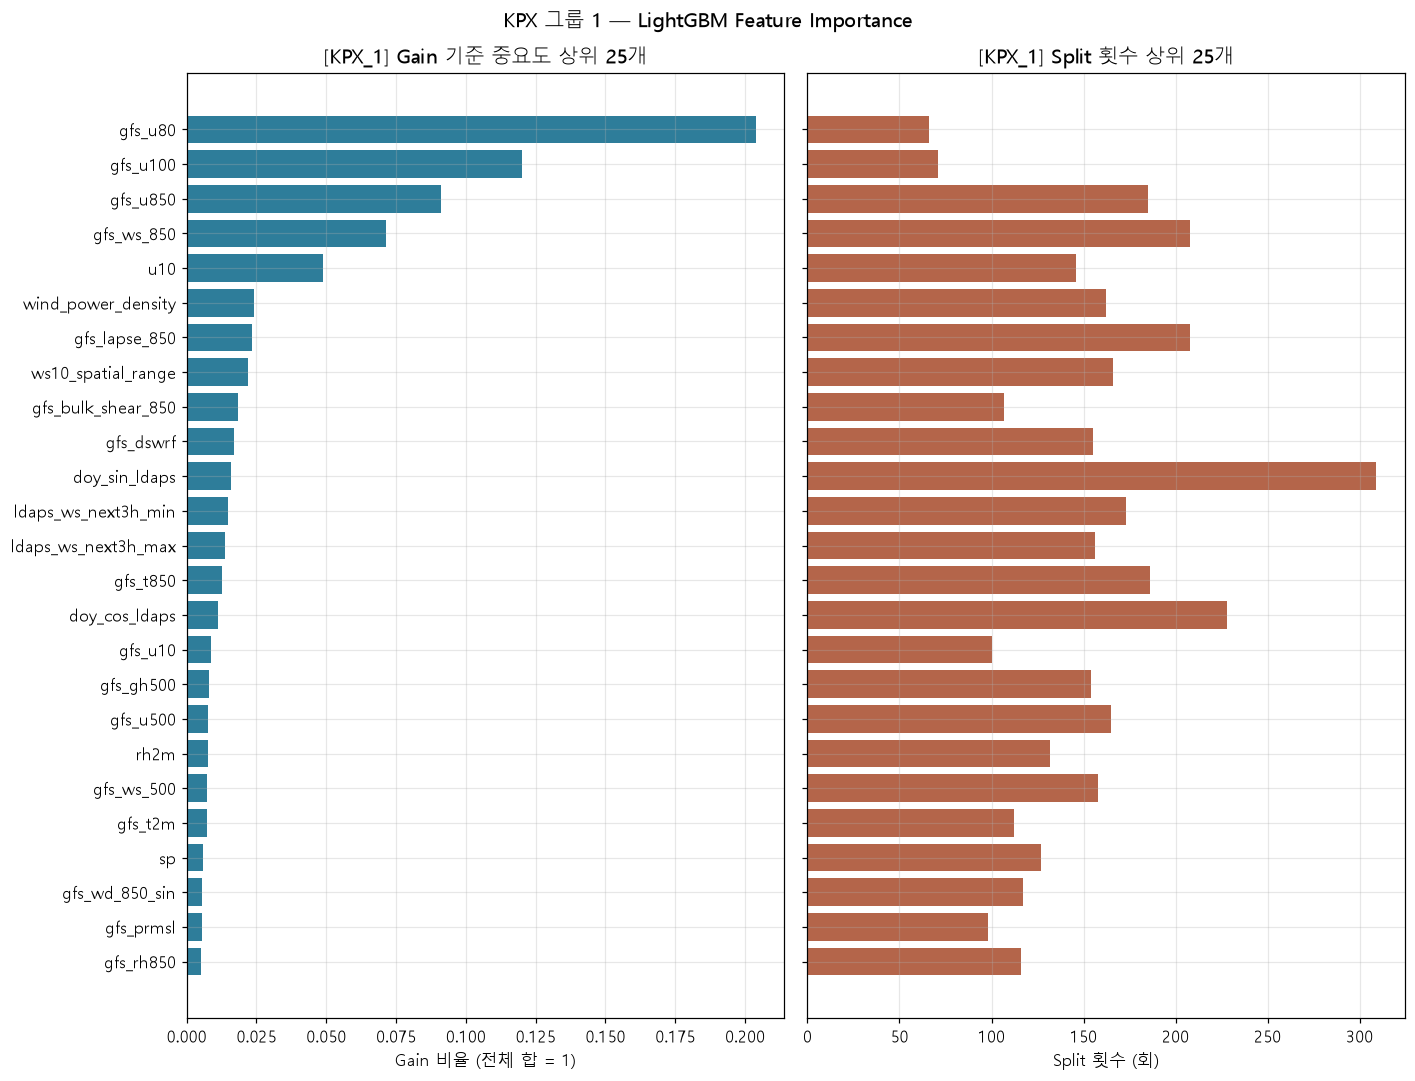

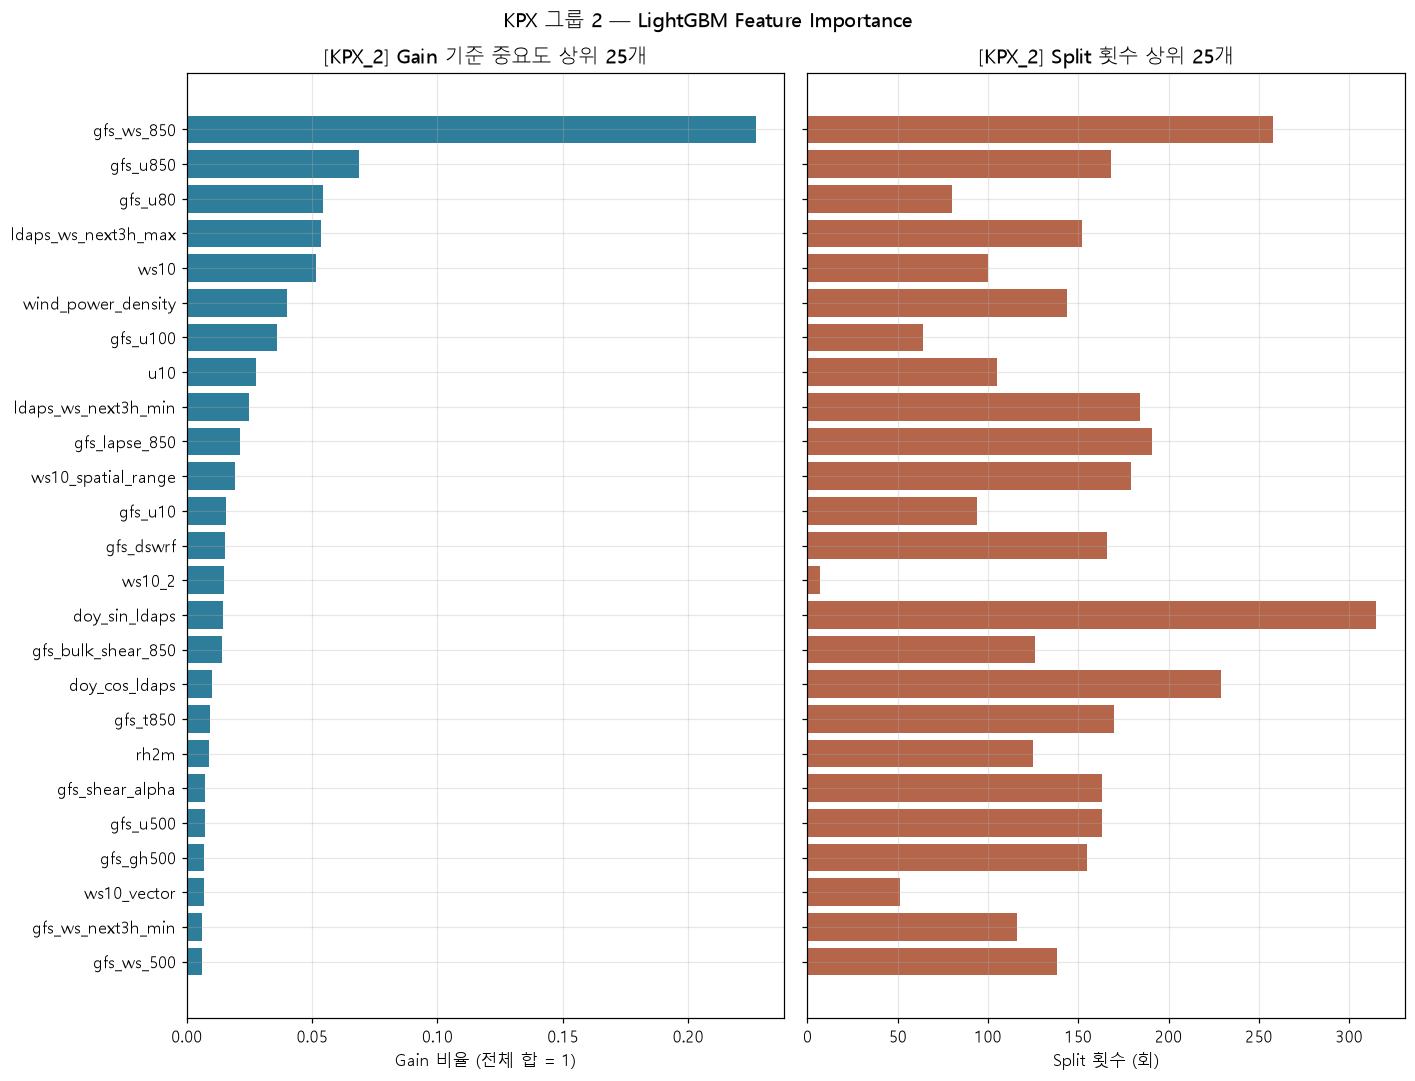

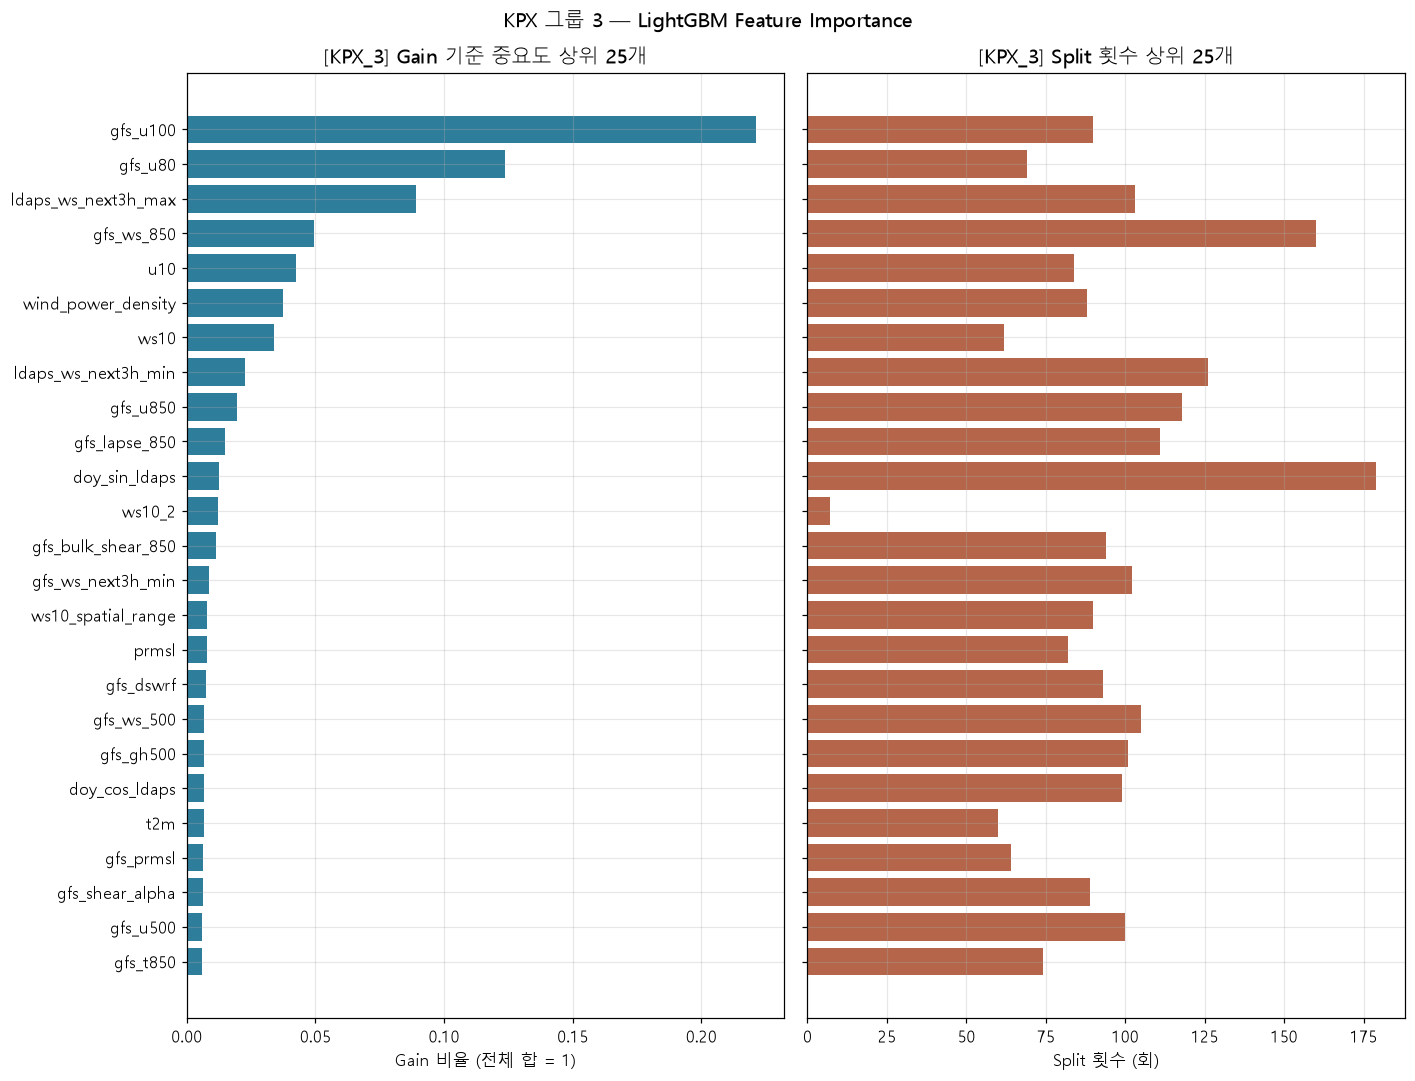

In [15]:
def plotFeatureImportance(model: lgb.LGBMRegressor, feat_cols: list[str],
                          group: int, top_n: int = 25) -> pd.DataFrame:
    """LightGBM의 gain·split 중요도를 나란히 시각화하는 함수

    Args:
        - model: 학습이 끝난 LGBMRegressor
        - feat_cols: 학습에 사용한 피처 컬럼 목록 (순서가 모델과 같아야 한다)
        - top_n: 막대그래프에 표시할 상위 피처 수

    Returns:
        - gain 기준 내림차순 정렬한 중요도 DataFrame

    Logic:
        - gain  : 그 피처로 분기했을 때 줄어든 손실의 총합 → "얼마나 잘 설명하는가"
        - split : 그 피처가 분기 기준으로 선택된 횟수 → "얼마나 자주 쓰이는가"
        - 둘이 어긋나는 피처(자주 쓰이지만 gain이 낮음)는 노이즈 분할일 가능성이 높다
    """
    importance = pd.DataFrame({
        "feature": feat_cols,
        "gain": model.booster_.feature_importance(importance_type="gain"),
        "split": model.booster_.feature_importance(importance_type="split"),
    }).sort_values("gain", ascending=False).reset_index(drop=True)
    importance["gain_ratio"] = importance["gain"] / importance["gain"].sum()
    # 전체 대비 비율로 바꿔 그룹 간 비교가 가능하게 한다

    top = importance.head(top_n).iloc[::-1]
    # 가로 막대는 아래에서 위로 그려지므로 순서를 뒤집는다

    fig, axes = plt.subplots(1, 2, figsize=(13, 0.34 * top_n + 1.5), sharey=True)
    axes[0].barh(top["feature"], top["gain_ratio"], color="#2E7D9A")
    axes[0].set_title(f"[KPX_{group}] Gain 기준 중요도 상위 {top_n}개")
    axes[0].set_xlabel("Gain 비율 (전체 합 = 1)")
    axes[1].barh(top["feature"], top["split"], color="#B4654A")
    axes[1].set_title(f"[KPX_{group}] Split 횟수 상위 {top_n}개")
    axes[1].set_xlabel("Split 횟수 (회)")
    fig.suptitle(f"KPX 그룹 {group} — LightGBM Feature Importance", fontsize=13)
    plt.tight_layout()
    plt.show()

    return importance


importance_store = {}
# {그룹번호: gain/split 중요도 DataFrame}
for g in GROUPS:
    importance_store[g] = plotFeatureImportance(models_full[g], datasets[g][1], g)

In [16]:
# 세 그룹의 gain 비율을 하나의 표로 합쳐 공통 상위 피처를 확인한다
gain_wide = pd.concat(
    [importance_store[g].set_index("feature")["gain_ratio"].rename(f"group_{g}") for g in GROUPS],
    axis=1,
)
gain_wide["mean_gain_ratio"] = gain_wide.mean(axis=1)
# 세 그룹 평균 gain 비율이 높을수록 그룹을 가리지 않고 유효한 피처다
gain_wide = gain_wide.sort_values("mean_gain_ratio", ascending=False)

print("=== 3그룹 평균 gain 비율 상위 20개 ===")
display(gain_wide.head(20))

=== 3그룹 평균 gain 비율 상위 20개 ===


,group_1,group_2,group_3,mean_gain_ratio
feature,,,,
gfs_u80,0.203729,0.054332,0.123622,0.127228
gfs_u100,0.120195,0.036120,0.221062,0.125792
gfs_ws_850,0.071507,0.226884,0.049578,0.115989
gfs_u850,0.091058,0.068840,0.019364,0.059754
ldaps_ws_next3h_max,0.013833,0.053695,0.089067,0.052198
u10,0.048725,0.027818,0.042328,0.039624
wind_power_density,0.024120,0.040097,0.037237,0.033818
ws10,0.004070,0.051419,0.033906,0.029798
ldaps_ws_next3h_min,0.014693,0.024961,0.022758,0.020804


---
## Step 3. SHAP Summary Plot — 기여도·방향성·비선형 관계

Feature Importance(gain)는 중요도만 알려주고 작용방식는 알려주지 않는다.
SHAP은 개별 예측을 피처별 기여도로 분해하므로 다음을 함께 읽을 수 있다.

| 읽는 법 | 의미 |
|---|---|
| 점의 **가로 위치** (SHAP value) | 그 샘플의 예측 발전량을 얼마나 올리고/내렸는지 |
| 점의 **색** (빨강=피처값 큼, 파랑=작음) | 피처값의 방향성: 빨강이 오른쪽이면 "값이 클수록 발전량 ↑" |
| 점의 **퍼짐** | 같은 피처값이라도 상황에 따라 기여가 다름 = 다른 피처와의 **상호작용** |
| **휘어지는 패턴** | 파워커브처럼 구간마다 기울기가 다른 **비선형 영향** |

In [17]:
SHAP_SAMPLE_SIZE = 2000
# 검증 구간 전체로 SHAP을 계산하면 느리므로 대표 표본만 사용한다

shap_store = {}
# {그룹번호: (shap_values, sample_df, shap_importance Series)}

for g in GROUPS:
    _, feat_cols, _, X_valid, _, _ = datasets[g]
    sample = X_valid.sample(min(SHAP_SAMPLE_SIZE, len(X_valid)), random_state=SEED)
    # 시각화 속도를 위해 검증 구간에서 무작위 표본 추출 (random_state로 재현성 확보)

    started = time.time()
    explainer = shap.TreeExplainer(models_full[g])
    # TreeExplainer: 트리 구조를 직접 순회해 정확한 Shapley value를 빠르게 계산한다
    shap_values = explainer.shap_values(sample)
    # shape = (표본 수, 피처 수). 값의 단위는 '이용률' 기여도다

    shap_importance = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=feat_cols)
        .sort_values(ascending=False)
    )
    # |SHAP|의 평균 = 예측에 미친 평균 영향력. gain과 달리 방향을 상쇄하지 않는다

    shap_store[g] = (shap_values, sample, shap_importance)
    print(f"[그룹{g}] SHAP 계산 완료 {shap_values.shape} ({time.time() - started:.1f}s)")

[그룹1] SHAP 계산 완료 (2000, 127) (1.4s)


[그룹2] SHAP 계산 완료 (2000, 127) (1.5s)


[그룹3] SHAP 계산 완료 (2000, 127) (0.9s)


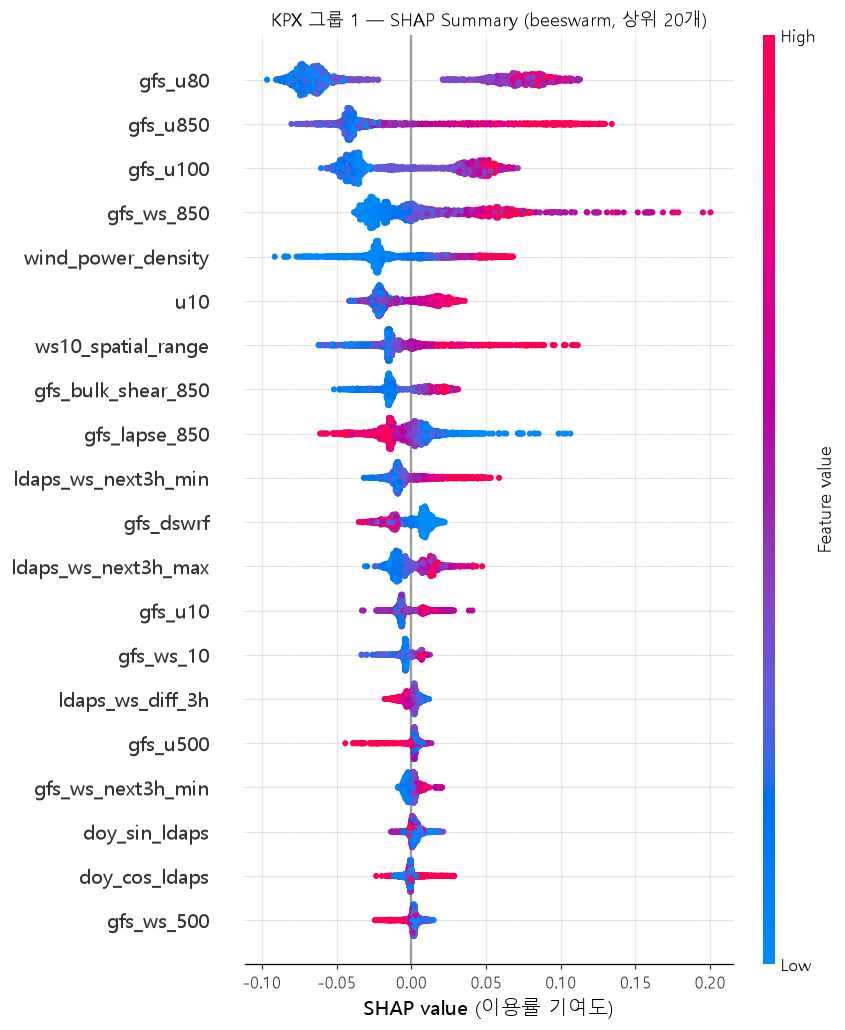

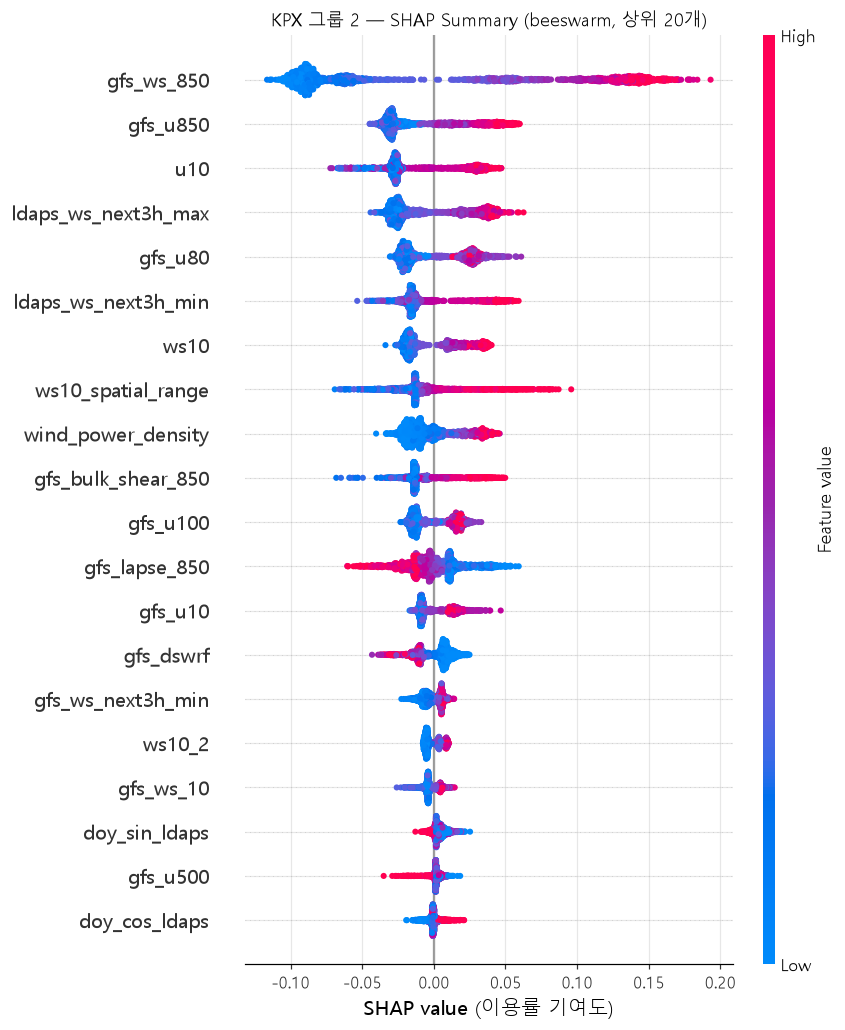

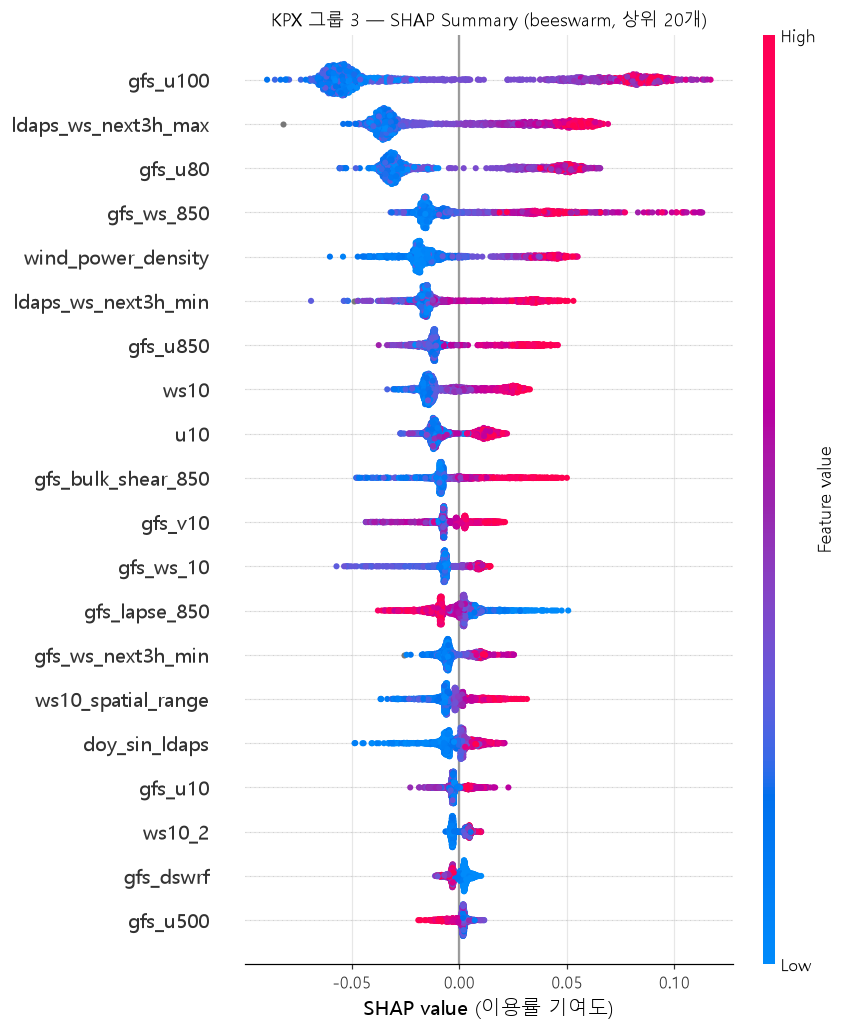

In [18]:
for g in GROUPS:
    shap_values, sample, _ = shap_store[g]

    plt.figure()
    shap.summary_plot(shap_values, sample, max_display=20, show=False)
    # beeswarm: 피처별 기여도 분포 + 피처값 방향성(색)을 한 화면에 보여준다
    plt.title(f"KPX 그룹 {g} — SHAP Summary (beeswarm, 상위 20개)", fontsize=12)
    plt.xlabel("SHAP value (이용률 기여도)")
    plt.tight_layout()
    plt.show()

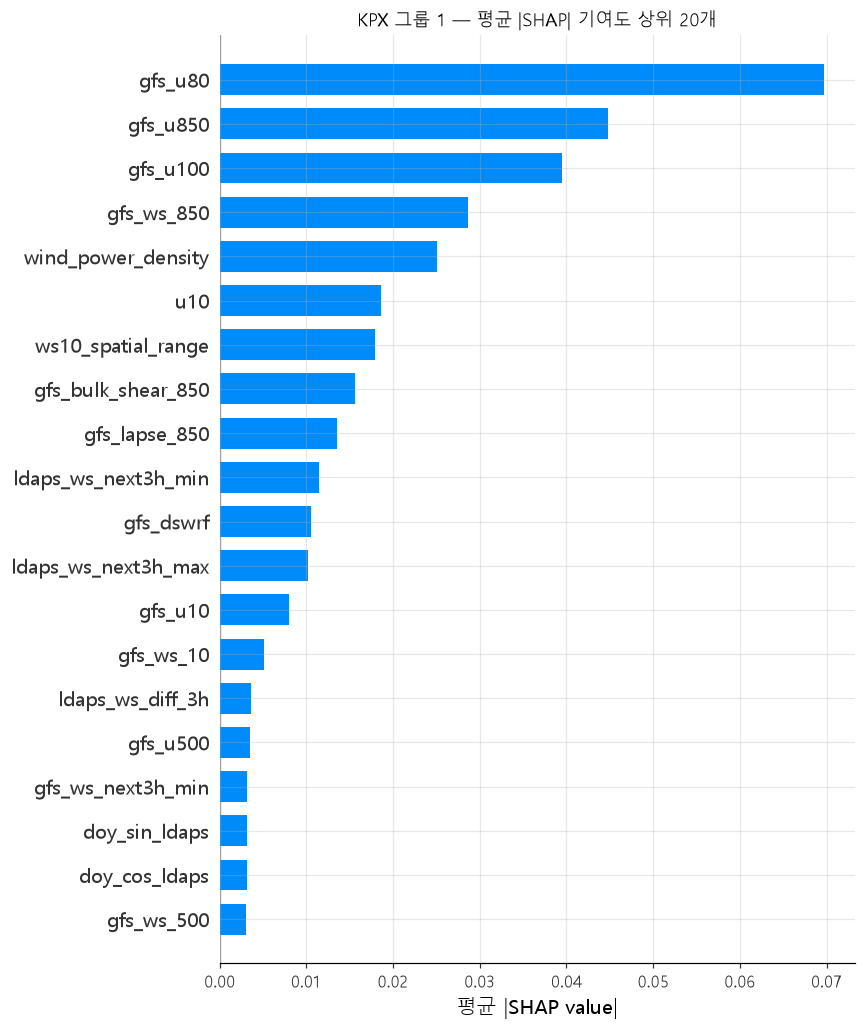

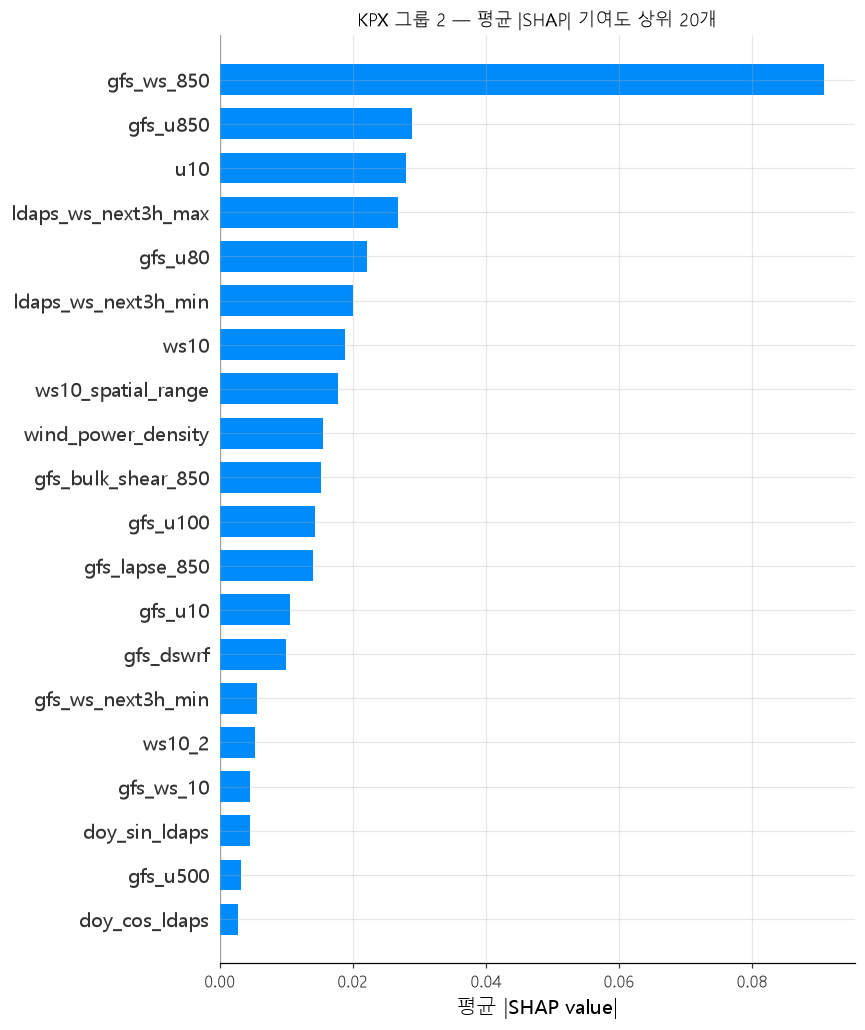

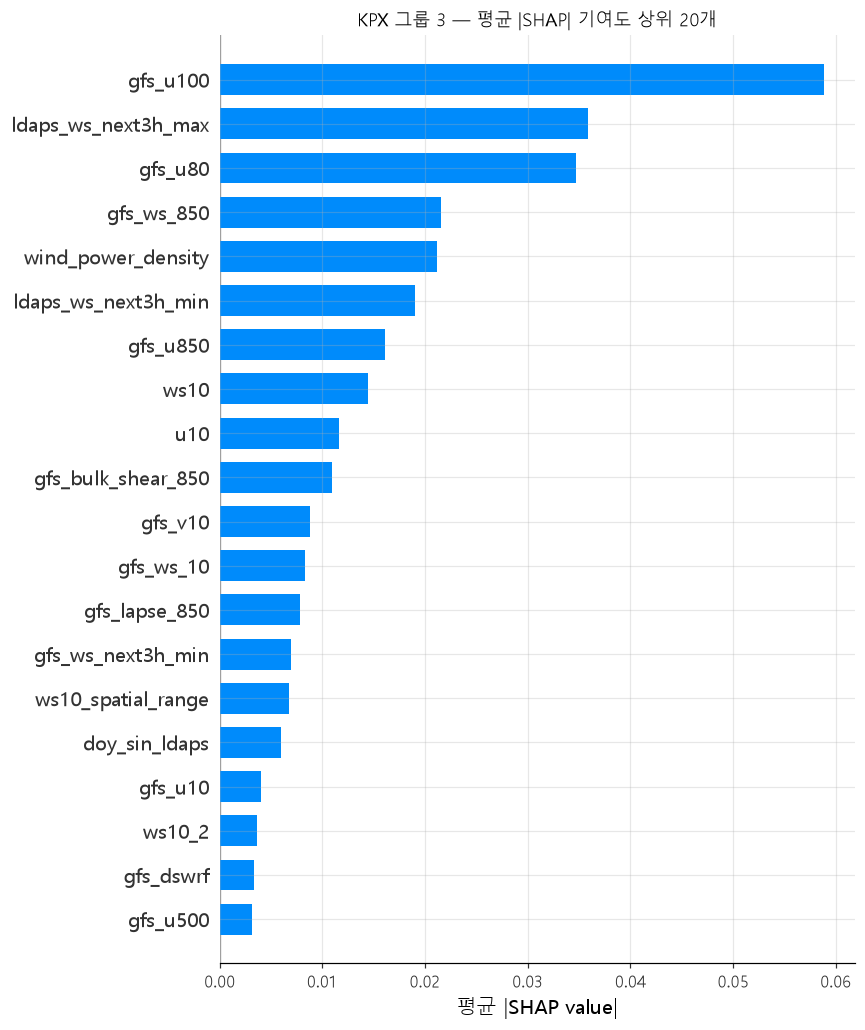

In [19]:
for g in GROUPS:
    shap_values, sample, _ = shap_store[g]

    plt.figure()
    shap.summary_plot(shap_values, sample, plot_type="bar", max_display=20, show=False)
    # bar: |SHAP| 평균만 뽑은 순위표. 피처 선별의 1차 기준으로 쓴다
    plt.title(f"KPX 그룹 {g} — 평균 |SHAP| 기여도 상위 20개", fontsize=12)
    plt.xlabel("평균 |SHAP value|")
    plt.tight_layout()
    plt.show()

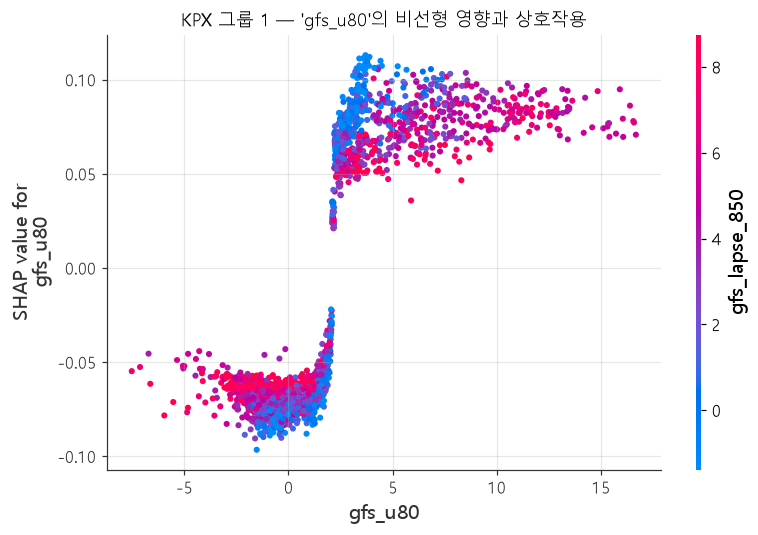

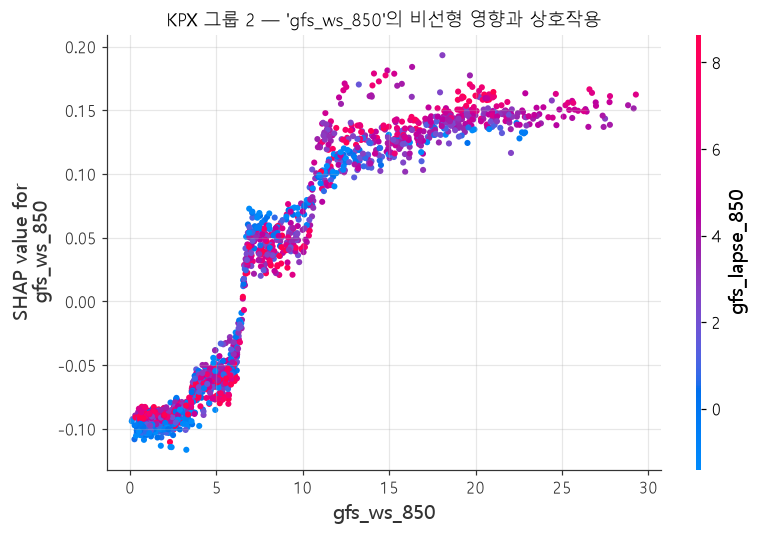

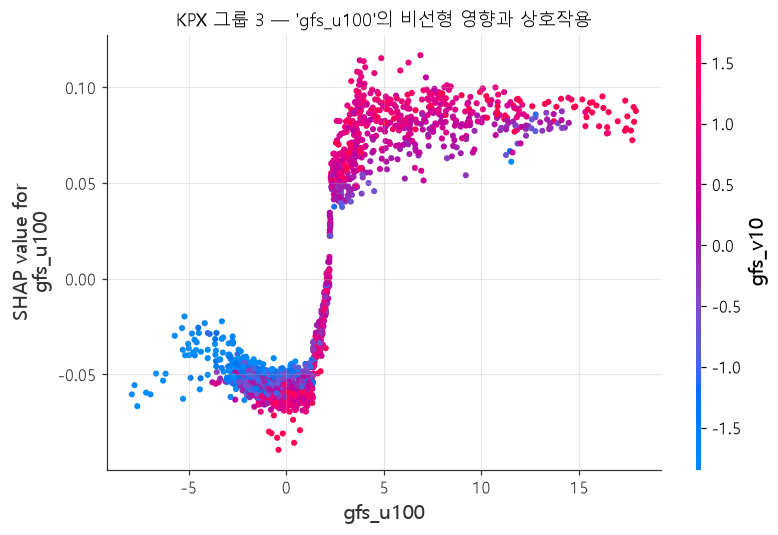

In [20]:
# 최상위 피처의 비선형 관계를 dependence plot으로 확인한다
for g in GROUPS:
    shap_values, sample, shap_importance = shap_store[g]
    top_feature = shap_importance.index[0]
    # 평균 |SHAP|이 가장 큰 피처

    shap.dependence_plot(
        top_feature, shap_values, sample,
        interaction_index = "auto",
        # auto: 상호작용이 가장 강한 피처를 자동으로 골라 점 색상으로 표시한다
        show = False,
    )
    plt.title(f"KPX 그룹 {g} — '{top_feature}'의 비선형 영향과 상호작용", fontsize=12)
    plt.tight_layout()
    plt.show()
    # 풍속 계열 피처라면 컷인(3m/s) 부근에서 기울기가 급해지는 S자 파워커브가 나타나야 정상이다

---
## Step 4. 피처 셀렉션

127개 피처 중 상당수는 **서로 거의 같은 정보**(예: `ws10`, `ws10_2`, `ws10_3`, `ws10_vector`)이거나
**무작위 노이즈보다 기여가 작다**. 세 가지 기준을 순서대로 적용해 걸러낸다.

| 단계 | 기준 | 근거 |
|---|---|---|
| ① 노이즈 임계 | 무작위 정규난수 피처 3개를 함께 학습시키고, 그 최대 |SHAP|보다 기여가 작은 피처를 제거 | 절대 임계값을 임의로 정하지 않고 **데이터가 스스로 기준선을 만들게** 한다 |
| ② 상관 중복 제거 | 학습 구간 \|상관계수\| > 0.95인 쌍에서 SHAP 순위가 낮은 쪽 제거 | 트리 모델은 중복 피처에 중요도를 나눠 가져 해석이 흐려지고 분산이 커진다 |
| ③ 누적 기여도 | 잔여 피처를 SHAP 순으로 정렬해 누적 기여 상위 `CUMULATIVE_RATIO`까지만 유지 | 꼬리 피처가 분산만 늘리는 데이터셋에서 사용하는 안전장치 |

> ①은 "null importance" 기법이다. 노이즈 피처는 정의상 타깃과 무관한데도 트리가 우연히 분할에 쓰므로,
> 그 기여도가 **우연히 얻을 수 있는 최대 기여도**의 실측 하한이 된다.

### ③의 임계값은 실측으로 정한다

이 데이터에서는 ①②를 통과한 꼬리 피처가 해롭지 않았다. 네 가지 값을 직접 학습·평가해 비교한 결과다.

| `cumulative_ratio` | 그룹별 잔여 피처 수 | 3그룹 평균 총점 |
|---|---|---|
| 0.99  | 74 / 73 / 70 | 0.6576 |
| 0.995 | 78 / 79 / 75 | 0.6557 |
| 0.999 | 84 / 84 / 80 | 0.6562 |
| **1.00 (미적용)** | **86 / 86 / 82** | **0.6592** |

차이는 0.003 수준으로 작지만 꼬리 절단이 이득을 주지 않으므로 **기본값을 `1.0`(미적용)으로 두고**,
실제 제거는 ①②가 담당한다. 다른 데이터셋에서 피처 수를 더 줄여야 할 때 이 값을 낮추면 된다.

In [21]:
class FeatureSelector:
    """SHAP 기여도·노이즈 기준선·상관 중복을 조합해 피처를 선별하는 클래스

    사용 순서:
        selector = FeatureSelector(capacity_kw = RATED_CAPACITY_KW[1])
        selected = selector.select(X_train, y_train, X_valid, y_valid, shap_importance)
        selector.report_   # 단계별 제거 내역 DataFrame
    """

    def __init__(self, capacity_kw: float, corr_threshold: float = CORR_THRESHOLD,
                 noise_count: int = NOISE_FEATURE_COUNT,
                 cumulative_ratio: float = CUMULATIVE_RATIO,
                 seed: int = SEED):
        self.capacity_kw = capacity_kw
        # 이용률 변환에 쓸 그룹 설비용량(kW)
        self.corr_threshold = corr_threshold
        # 이 값을 넘는 상관을 중복으로 간주
        self.noise_count = noise_count
        # 기준선을 만들 무작위 노이즈 피처 개수
        self.cumulative_ratio = cumulative_ratio
        # 누적 SHAP 기여도 유지 비율
        self.seed = seed
        self.report_: Optional[pd.DataFrame] = None
        # select() 실행 후 단계별 제거 내역이 저장된다
        self.noise_threshold_: Optional[float] = None
        # 노이즈 피처가 만든 기여도 하한선

    def _computeNoiseThreshold(self, X_train: pd.DataFrame, y_train: np.ndarray,
                               X_valid: pd.DataFrame, y_valid: np.ndarray,
                               sample_index: pd.Index) -> pd.Series:
        """무작위 노이즈 피처를 섞어 학습한 뒤 피처별 |SHAP| 평균을 반환하는 내부 헬퍼 메서드

        Logic:
            - 노이즈는 타깃과 아무 관계가 없으므로, 그 기여도는 '우연히 얻어지는 기여도'의 실측값이다
            - 노이즈 3개 중 최댓값을 임계로 삼아 보수적으로 판단한다
        """
        rng = np.random.default_rng(self.seed)
        X_train_noise = X_train.copy()
        X_valid_noise = X_valid.copy()
        # 원본 DataFrame 변형 방지

        for i in range(self.noise_count):
            X_train_noise[f"__noise_{i}"] = rng.normal(size=len(X_train_noise))
            X_valid_noise[f"__noise_{i}"] = rng.normal(size=len(X_valid_noise))
            # 표준정규 난수 피처를 학습·검증 양쪽에 동일하게 추가

        model = trainLightGBM(X_train_noise, y_train, X_valid_noise, y_valid, self.capacity_kw)
        sample = X_valid_noise.loc[sample_index]
        # Step 3과 동일한 표본에서 SHAP을 계산해 비교 가능성을 유지한다
        shap_values = shap.TreeExplainer(model).shap_values(sample)

        importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_noise.columns)
        self.noise_threshold_ = float(
            importance[[f"__noise_{i}" for i in range(self.noise_count)]].max()
        )
        # 노이즈 피처들의 최대 기여도 = 제거 임계선
        return importance

    def select(self, X_train: pd.DataFrame, y_train: np.ndarray,
               X_valid: pd.DataFrame, y_valid: np.ndarray,
               shap_importance: pd.Series, sample_index: pd.Index) -> list[str]:
        """3단계 기준으로 유의미한 피처만 남기는 메서드

        Args:
            - shap_importance: Step 3에서 계산한 |SHAP| 평균 Series (내림차순)
            - sample_index: SHAP 계산에 쓴 검증 표본의 인덱스

        Returns:
            - 선별된 피처 컬럼 목록 (SHAP 중요도 내림차순)
        """
        feat_cols = list(X_train.columns)
        rows = []
        # 피처별 판정 사유를 기록할 리스트

        noise_importance = self._computeNoiseThreshold(
            X_train, y_train, X_valid, y_valid, sample_index
        )
        survived = [c for c in feat_cols if noise_importance.get(c, 0.0) > self.noise_threshold_]
        dropped_noise = [c for c in feat_cols if c not in survived]
        print(f"  ① 노이즈 임계 {self.noise_threshold_:.3e} → {len(dropped_noise)}개 제거, {len(survived)}개 생존")

        corr = X_train[survived].corr().abs()
        # 학습 구간에서만 상관을 계산한다 (검증 구간 정보 유입 차단)
        ordered = [c for c in shap_importance.index if c in survived]
        # SHAP 중요도가 높은 피처부터 검사해 중요한 쪽을 남긴다
        selected, dropped_corr = [], []
        for col in ordered:
            duplicated = next(
                (kept for kept in selected if corr.loc[col, kept] > self.corr_threshold), None
            )
            if duplicated is not None:
                dropped_corr.append((col, duplicated))
                # 이미 선택된 피처와 사실상 같은 정보 → 제거
            else:
                selected.append(col)
        print(f"  ② 상관 {self.corr_threshold} 초과 중복 → {len(dropped_corr)}개 제거, {len(selected)}개 생존")

        ranked = shap_importance.loc[selected]
        if self.cumulative_ratio >= 1.0:
            final = list(ranked.index)
            # cumulative_ratio = 1.0이면 꼬리 절단을 하지 않는다 (이 데이터의 실측 최적값)
        else:
            cumulative = ranked.cumsum() / ranked.sum()
            keep_count = int((cumulative < self.cumulative_ratio).sum()) + 1
            # 누적 기여도가 목표 비율에 도달하는 지점까지만 유지
            final = list(ranked.index[:keep_count])
        dropped_tail = [c for c in selected if c not in final]
        print(f"  ③ 누적 기여 {self.cumulative_ratio:.1%} → {len(dropped_tail)}개 제거, 최종 {len(final)}개")

        for col in feat_cols:
            if col in dropped_noise:
                reason = "노이즈 이하"
            elif col in [c for c, _ in dropped_corr]:
                reason = f"중복({dict(dropped_corr)[col]})"
            elif col in dropped_tail:
                reason = "누적 기여 꼬리"
            else:
                reason = "선택"
            rows.append({"feature": col, "shap_importance": float(shap_importance.get(col, 0.0)),
                         "decision": reason})
        self.report_ = pd.DataFrame(rows).sort_values("shap_importance", ascending=False).reset_index(drop=True)
        # 어떤 피처가 왜 빠졌는지 추적 가능하게 남긴다

        return final

In [22]:
selected_features = {}
# {그룹번호: 선별된 피처 목록}
selection_reports = {}
# {그룹번호: 단계별 판정 내역 DataFrame}

for g in GROUPS:
    _, feat_cols, X_train, X_valid, y_train, y_valid = datasets[g]
    _, sample, shap_importance = shap_store[g]

    print(f"[그룹{g}] 피처 선별 시작 (전체 {len(feat_cols)}개)")
    selector = FeatureSelector(capacity_kw=RATED_CAPACITY_KW[g])
    selected_features[g] = selector.select(
        X_train, y_train, X_valid, y_valid, shap_importance, sample.index
    )
    selection_reports[g] = selector.report_
    print()

[그룹1] 피처 선별 시작 (전체 127개)


  ① 노이즈 임계 5.242e-05 → 4개 제거, 123개 생존


  ② 상관 0.95 초과 중복 → 37개 제거, 86개 생존
  ③ 누적 기여 100.0% → 0개 제거, 최종 86개

[그룹2] 피처 선별 시작 (전체 127개)


  ① 노이즈 임계 1.751e-04 → 5개 제거, 122개 생존


  ② 상관 0.95 초과 중복 → 36개 제거, 86개 생존
  ③ 누적 기여 100.0% → 0개 제거, 최종 86개

[그룹3] 피처 선별 시작 (전체 127개)


  ① 노이즈 임계 1.563e-04 → 13개 제거, 114개 생존


  ② 상관 0.95 초과 중복 → 32개 제거, 82개 생존
  ③ 누적 기여 100.0% → 0개 제거, 최종 82개



In [23]:
# 세 그룹에서 모두 선택된 피처 = 그룹을 가리지 않는 핵심 신호
common_selected = sorted(set.intersection(*[set(selected_features[g]) for g in GROUPS]))
print(f"3그룹 공통 선택 피처: {len(common_selected)}개")
print(common_selected[:40])

print("\n=== [그룹1] 제거 사유별 피처 수 ===")
display(selection_reports[1]["decision"].value_counts().rename("피처 수").to_frame())

print("=== [그룹1] 상위 15개 판정 내역 ===")
display(selection_reports[1].head(15))

3그룹 공통 선택 피처: 72개
['blh', 'blws', 'doy_cos_ldaps', 'doy_sin_ldaps', 'dpt2m', 'gfs_dlwrf', 'gfs_dswrf', 'gfs_gh500', 'gfs_gust', 'gfs_gust_factor', 'gfs_hcc', 'gfs_lapse_850', 'gfs_lcc', 'gfs_mcc', 'gfs_pbl_v', 'gfs_prate', 'gfs_rh850', 'gfs_shear_alpha', 'gfs_tcc', 'gfs_tp', 'gfs_u500', 'gfs_u850', 'gfs_u_diff_1h', 'gfs_v10', 'gfs_v500', 'gfs_v850', 'gfs_v_diff_1h', 'gfs_vrate', 'gfs_wd_10', 'gfs_wd_10_cos', 'gfs_wd_500', 'gfs_wd_500_cos', 'gfs_wd_500_sin', 'gfs_wd_850', 'gfs_wd_850_cos', 'gfs_wd_850_sin', 'gfs_wd_pbl', 'gfs_wd_pbl_cos', 'gfs_wd_rotation', 'gfs_ws_10']

=== [그룹1] 제거 사유별 피처 수 ===


,피처 수
decision,
선택,86
노이즈 이하,4
중복(gfs_u80),3
중복(gfs_wd_10_sin),3
중복(gfs_ws_10),3
중복(gfs_t850),2
중복(gfs_wd_10_cos),2
중복(gfs_v10),2
중복(wind_power_density),2


=== [그룹1] 상위 15개 판정 내역 ===


,feature,shap_importance,decision
0,gfs_u80,0.069762,선택
1,gfs_u850,0.044754,선택
2,gfs_u100,0.039451,중복(gfs_u80)
3,gfs_ws_850,0.028665,선택
4,wind_power_density,0.025048,선택
5,u10,0.018558,선택
6,ws10_spatial_range,0.017903,선택
7,gfs_bulk_shear_850,0.015608,중복(gfs_ws_850)
8,gfs_lapse_850,0.013506,선택
9,ldaps_ws_next3h_min,0.011454,선택


In [24]:
# 선별 결과를 파일로 남겨 다른 노트북·스크립트가 그대로 재사용할 수 있게 한다
selection_path = f"{PREP_DIR}/selected_features.csv"
selection_df = pd.concat(
    [pd.DataFrame({"group": g, "feature": selected_features[g],
                   "rank": range(1, len(selected_features[g]) + 1)}) for g in GROUPS],
    ignore_index=True,
)
selection_df.to_csv(selection_path, index=False, encoding="utf-8-sig")
print(f"선별 피처 저장 완료: {selection_path} ({selection_df.shape[0]}행)")

선별 피처 저장 완료: d:/workspaces/WINDFORCE/prep/selected_features.csv (254행)


---
## Step 5. 재학습 및 baseline 5 대비 성능 비교

선별한 피처만으로 동일한 하이퍼파라미터·동일한 시간순 분할에서 재학습한다.
비교 대상은 세 가지다.

| 비교 대상 | 의미 |
|---|---|
| `LGBM_full` | 127개 전체 피처 — 피처 선별의 순수 효과를 본다 |
| `LGBM_selected` | 선별 피처 — 이 노트북의 제안 모델 |
| baseline 5 기록 (`baseline_5_results.csv`) | LSTM / SVR / Persistence의 기존 점수 |

평가지표는 대회 공식 **총점 = 0.5×(1-NMAE) + 0.5×FICR** (클수록 좋음)을 주 지표로 하고,
직관적 비교를 위해 MAE·RMSE(kWh)를 함께 표시한다.

In [25]:
models_selected = {}
# {그룹번호: 선별 피처로 학습한 LGBMRegressor}

for g in GROUPS:
    _, _, X_train, X_valid, y_train, y_valid = datasets[g]
    cols = selected_features[g]
    capacity_kw = RATED_CAPACITY_KW[g]

    model = trainLightGBM(X_train[cols], y_train, X_valid[cols], y_valid, capacity_kw)
    models_selected[g] = model
    # 선별 피처 모델을 그룹별로 보관 (Step 6 제출 생성에 재사용)

    pred = predictKw(model, X_valid[cols], capacity_kw)
    result = summarizeAll(pred, y_valid, g)
    records.append({"group": g, "model_name": "LGBM_selected", "n_features": len(cols), **result})

    print(f"[그룹{g}] 피처 {len(cols)}개 | 트리 {model.best_iteration_}개 | "
          f"NMAE={result['nmae']:.4f}  FICR={result['ficr']:.4f}  총점={result['score']:.4f}  "
          f"MAE={result['mae']:,.0f}kWh")

[그룹1] 피처 86개 | 트리 131개 | NMAE=0.0805  FICR=0.3913  총점=0.6554  MAE=1,740kWh


[그룹2] 피처 86개 | 트리 249개 | NMAE=0.0794  FICR=0.4302  총점=0.6754  MAE=1,714kWh


[그룹3] 피처 82개 | 트리 94개 | NMAE=0.0712  FICR=0.3650  총점=0.6469  MAE=1,495kWh


In [26]:
result_df = pd.DataFrame(records).drop_duplicates(subset=["group", "model_name"], keep="last")
# 셀을 여러 번 실행해도 중복 행이 쌓이지 않도록 마지막 결과만 남긴다

print("=== 그룹별 상세 지표 ===")
display(result_df.pivot(index="model_name", columns="group", values=["nmae", "ficr", "score"]))

=== 그룹별 상세 지표 ===


nmae                       ficr                    \
group                          1        2        3        1        2        3   
model_name                                                                      
LGBM_full               0.080859 0.079706 0.071847 0.388029 0.424407 0.358486   
LGBM_selected           0.080538 0.079358 0.071183 0.391304 0.430158 0.364959   
Persistence_oracle_lag1 0.050445 0.047475 0.042481 0.623935 0.667353 0.625559   

                           score                    
group                          1        2        3  
model_name                                          
LGBM_full               0.653585 0.672350 0.643320  
LGBM_selected           0.655383 0.675400 0.646888  
Persistence_oracle_lag1 0.786745 0.809939 0.791539

In [27]:
def aggregateOfficialScore(df: pd.DataFrame) -> pd.DataFrame:
    """모델별로 3그룹 지표를 먼저 평균한 뒤 대회 공식 총점을 계산하는 함수

    Logic:
        - 총점 = 0.5×(1 - 평균 NMAE) + 0.5×(평균 FICR)
        - 그룹별 score를 단순 평균한 값과 미묘하게 다를 수 있어 별도로 집계한다
    """
    columns = {"mean_nmae": ("nmae", "mean"), "mean_ficr": ("ficr", "mean")}
    if "mae" in df.columns:
        columns |= {"mean_mae": ("mae", "mean"), "mean_rmse": ("rmse", "mean")}
    summary = df.groupby("model_name", as_index=False).agg(**columns)
    summary["official_score"] = 0.5 * (1 - summary["mean_nmae"]) + 0.5 * summary["mean_ficr"]
    return summary.sort_values("official_score", ascending=False).reset_index(drop=True)


howto_summary = aggregateOfficialScore(result_df)
print("=== 이 노트북(baseline5_howto) 총점 ===")
display(howto_summary)

baseline5_path = f"{ROOT}/BASELINE/baseline_5_results.csv"
baseline5_df = pd.read_csv(baseline5_path, encoding="utf-8-sig")
baseline5_summary = aggregateOfficialScore(baseline5_df)
print("=== baseline 5 기록 총점 ===")
display(baseline5_summary)

=== 이 노트북(baseline5_howto) 총점 ===


,model_name,mean_nmae,mean_ficr,mean_mae,mean_rmse,official_score
0,Persistence_oracle_lag1,0.046800,0.638949,"1,002.391957","1,682.416386",0.796074
1,LGBM_selected,0.077026,0.395474,"1,649.534896","2,620.373076",0.659224
2,LGBM_full,0.077471,0.390307,"1,658.996032","2,634.629420",0.656418


=== baseline 5 기록 총점 ===


,model_name,mean_nmae,mean_ficr,official_score
0,Persistence_oracle_lag1,0.046800,0.638949,0.796074
1,LSTM,0.198398,0.184359,0.492981
2,SVR,0.227950,0.082790,0.427420


In [28]:
# 두 노트북 결과를 하나의 비교표로 합친다
COMPARE_COLS = ["source", "model_name", "mean_nmae", "mean_ficr", "official_score"]
# baseline 5 기록에는 MAE·RMSE가 없으므로 공통 컬럼만 사용한다

compare_df = pd.concat([
    baseline5_summary.assign(source="baseline_5")[COMPARE_COLS],
    howto_summary.assign(source="baseline5_howto")[COMPARE_COLS],
], ignore_index=True)
compare_df = compare_df[
    ~((compare_df["source"] == "baseline5_howto") & (compare_df["model_name"] == "Persistence_oracle_lag1"))
].reset_index(drop=True)
# Persistence는 두 노트북에서 동일한 검증 구간·동일한 계산식이라 값이 같다. 중복 행을 하나만 남긴다

best_baseline = baseline5_summary.query("model_name == 'LSTM'")["official_score"].iloc[0]
# baseline 5의 제출 후보 모델(LSTM) 총점 — Persistence는 oracle이라 제출 불가
best_howto = howto_summary.query("model_name == 'LGBM_selected'")["official_score"].iloc[0]
delta = best_howto - best_baseline

print(f"baseline 5 LSTM 총점       : {best_baseline:.4f}")
print(f"baseline5_howto LGBM 총점  : {best_howto:.4f}")
print(f"개선폭                      : {delta:+.4f} ({delta / best_baseline:+.1%})")
display(compare_df.sort_values("official_score", ascending=False))

baseline 5 LSTM 총점       : 0.4930
baseline5_howto LGBM 총점  : 0.6592
개선폭                      : +0.1662 (+33.7%)


,source,model_name,mean_nmae,mean_ficr,official_score
0,baseline_5,Persistence_oracle_lag1,0.046800,0.638949,0.796074
3,baseline5_howto,LGBM_selected,0.077026,0.395474,0.659224
4,baseline5_howto,LGBM_full,0.077471,0.390307,0.656418
1,baseline_5,LSTM,0.198398,0.184359,0.492981
2,baseline_5,SVR,0.227950,0.082790,0.427420


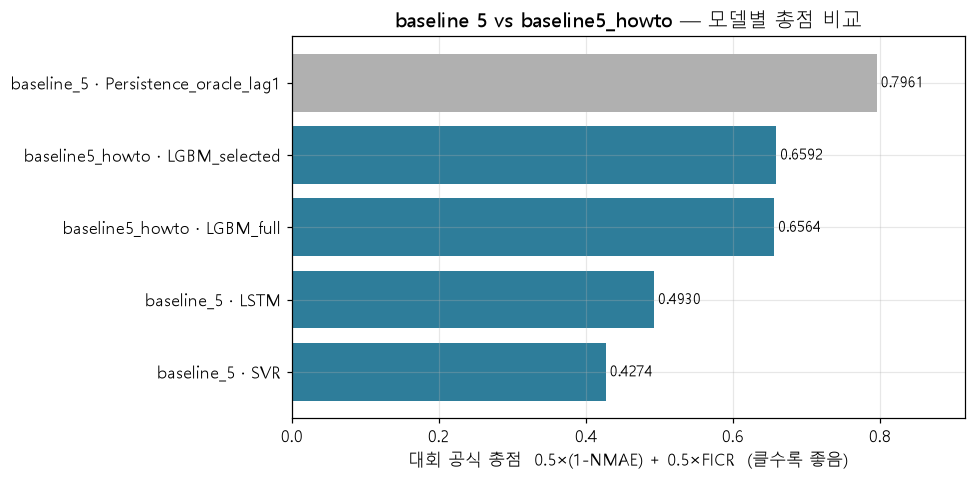

In [29]:
# 모델별 총점을 가로 막대로 비교한다 (제출 가능 여부를 색으로 구분)
plot_df = compare_df.copy()
plot_df["label"] = plot_df["source"] + " · " + plot_df["model_name"]
plot_df = plot_df.sort_values("official_score")

colors = ["#B0B0B0" if "Persistence" in name else "#2E7D9A" for name in plot_df["model_name"]]
# 회색 = 실제 제출에 사용할 수 없는 oracle 기준선

plt.figure(figsize=(9, 0.5 * len(plot_df) + 2))
bars = plt.barh(plot_df["label"], plot_df["official_score"], color=colors)
for bar, value in zip(bars, plot_df["official_score"]):
    plt.text(value + 0.005, bar.get_y() + bar.get_height() / 2, f"{value:.4f}",
             va="center", fontsize=10)
plt.xlabel("대회 공식 총점  0.5×(1-NMAE) + 0.5×FICR  (클수록 좋음)")
plt.title("baseline 5 vs baseline5_howto — 모델별 총점 비교", fontsize=13)
plt.xlim(0, max(plot_df["official_score"]) * 1.15)
plt.tight_layout()
plt.show()
# 회색 막대(Persistence)는 직전 실제값을 쓰는 참고 상한이므로 제출 후보 비교에서 제외해 읽는다

In [30]:
# 피처 선별의 순수 효과: 전체 피처 대비 선별 피처의 그룹별 변화량
effect_df = (result_df[result_df["model_name"].isin(["LGBM_full", "LGBM_selected"])]
             .pivot(index="group", columns="model_name", values=["score", "n_features", "mae"]))
effect_df[("score", "개선폭")] = effect_df[("score", "LGBM_selected")] - effect_df[("score", "LGBM_full")]
effect_df[("n_features", "감소율")] = (
    1 - effect_df[("n_features", "LGBM_selected")] / effect_df[("n_features", "LGBM_full")]
)
print("=== 피처 선별 효과 (그룹별) ===")
display(effect_df)

=== 피처 선별 효과 (그룹별) ===


score               n_features                        mae  \
model_name LGBM_full LGBM_selected  LGBM_full LGBM_selected    LGBM_full   
group                                                                      
1           0.653585      0.655383 127.000000     86.000000 1,746.555648   
2           0.672350      0.675400 127.000000     86.000000 1,721.652062   
3           0.643320      0.646888 127.000000     82.000000 1,508.780387   

                            score n_features  
model_name LGBM_selected      개선폭        감소율  
group                                         
1           1,739.619356 0.001798   0.322835  
2           1,714.132869 0.003050   0.322835  
3           1,494.852462 0.003568   0.354331

In [31]:
# 그룹별 원본 지표를 저장해 리더보드 노트북에서 다른 baseline과 재집계할 수 있게 한다
results_path = f"{ROOT}/BASELINE/baseline5_howto_results.csv"
result_df.to_csv(results_path, index=False, encoding="utf-8-sig")
print(f"리더보드 입력용 결과 저장 완료: {results_path}")

리더보드 입력용 결과 저장 완료: d:/workspaces/WINDFORCE/BASELINE/baseline5_howto_results.csv


---
## Step 6. 제출 CSV 생성 (선택)

검증에서 가장 좋았던 **선별 피처 LightGBM**으로 2025년 전체(8,760시간)를 예측한다.

- 학습은 **검증 구간까지 포함한 전체 학습 데이터**로 다시 수행한다 (최종 모델은 데이터를 최대한 쓴다).
- 평가 피처는 `prep/dataset_test_group{g}.csv.gz`에서 읽고, **학습 피처 순서를 그대로 강제**한다
  (`improvement.md` 개선안 B — 컬럼 순서가 어긋나면 다른 변수가 다른 의미로 입력된다).

In [32]:
submission = loader["sample_submission"].copy()
# 제출 양식을 복사해 행 순서와 컬럼 구성을 원본과 동일하게 유지한다
submission["forecast_kst_dtm"] = pd.to_datetime(submission["forecast_kst_dtm"])
# 병합 키의 자료형을 datetime으로 통일

for g in GROUPS:
    target_col = f"kpx_group_{g}"
    cols = selected_features[g]
    capacity_kw = RATED_CAPACITY_KW[g]

    train_df = datasets[g][0]
    test_df = prep_builder.load(g, "test")
    # 평가 기간 전처리 완료본 로드

    missing = [c for c in cols if c not in test_df.columns]
    if missing:
        raise KeyError(f"[그룹{g}] 평가 데이터에 없는 선별 피처가 있습니다: {missing}")
        # 학습·평가 피처 불일치를 조용히 넘기지 않고 여기서 즉시 실패시킨다

    X_full = train_df[cols]
    y_full = train_df[target_col].to_numpy()
    # 검증 구간까지 포함한 전체 학습 데이터

    holdout = int(len(X_full) * (1 - TEST_RATIO))
    final_model = trainLightGBM(
        X_full.iloc[:holdout], y_full[:holdout],
        X_full.iloc[holdout:], y_full[holdout:],
        capacity_kw,
    )
    # 조기 종료 지점을 결정하기 위해 동일한 시간순 분할을 그대로 사용한다

    pred = predictKw(final_model, test_df[cols], capacity_kw)
    pred_series = pd.Series(pred, index=test_df["forecast_kst_dtm"])
    submission[target_col] = pred_series.reindex(submission["forecast_kst_dtm"]).to_numpy()
    # 예측값에 시각 인덱스를 붙인 뒤 sample_submission 순서로 재배열

    print(f"[그룹{g}] 피처 {len(cols)}개로 예측 완료. NaN 수: {submission[target_col].isna().sum()}")

submission = submission.ffill().fillna(0)
# 병합 누락 시 직전 예측으로 보완하고, 시작 구간의 잔여 결측은 0으로 처리
display(submission.head())

[그룹1] 피처 86개로 예측 완료. NaN 수: 0


[그룹2] 피처 86개로 예측 완료. NaN 수: 0


[그룹3] 피처 82개로 예측 완료. NaN 수: 0


,forecast_id,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,forecast_0001,2025-01-01 01:00:00,"17,264.219640","18,041.720883","18,409.718371"
1,forecast_0002,2025-01-01 02:00:00,"18,263.934550","19,091.112140","17,621.323125"
2,forecast_0003,2025-01-01 03:00:00,"18,012.874484","18,758.656409","16,789.477596"
3,forecast_0004,2025-01-01 04:00:00,"17,474.277656","18,922.171161","14,902.497234"
4,forecast_0005,2025-01-01 05:00:00,"17,275.914381","18,506.434926","15,308.818944"


In [33]:
# 제출 스키마, 결측치, 물리적으로 불가능한 음수 발전량을 차례로 확인한다
sample = loader["sample_submission"]
assert list(submission.columns) == list(sample.columns), "컬럼 순서 불일치!"
assert len(submission) == len(sample), f"행 수 불일치! 기대: {len(sample)}, 실제: {len(submission)}"
assert submission.isna().sum().sum() == 0, "제출 파일에 NaN 존재!"
for g in GROUPS:
    col = f"kpx_group_{g}"
    assert (submission[col] >= 0).all(), f"{col}에 음수 예측값 존재!"
    assert (submission[col] <= RATED_CAPACITY_KW[g]).all(), f"{col}에 설비용량 초과 예측값 존재!"
print("스키마 검증 통과 ✅")

out_path = f"{ROOT}/submission_baseline5_howto.csv"
submission.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"제출 파일 저장 완료: {out_path}")

스키마 검증 통과 ✅
제출 파일 저장 완료: d:/workspaces/WINDFORCE/submission_baseline5_howto.csv


In [34]:
# 예측이 상수로 무너지지 않았는지(=입력에 반응하는지) 최종 확인한다
for g in GROUPS:
    col = f"kpx_group_{g}"
    series = submission[col]
    print(f"[{col}] 고유값 {series.nunique():,}개 | 평균 {series.mean():,.0f} | "
          f"최소 {series.min():,.0f} | 최대 {series.max():,.0f} kWh")
    # baseline 3처럼 고유값이 2개뿐이면 모델이 입력을 무시하고 있다는 신호다

fig = px.line(
    submission.head(24 * 14), x="forecast_kst_dtm",
    y=[f"kpx_group_{g}" for g in GROUPS],
    title="제출 예측값 — 2025년 첫 2주 시간별 발전량",
    labels={"forecast_kst_dtm": "예보 대상 시각", "value": "예측 발전량 (kWh)",
            "variable": "KPX 그룹"},
    template="plotly_white",
)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

[kpx_group_1] 고유값 8,654개 | 평균 7,138 | 최소 0 | 최대 20,847 kWh
[kpx_group_2] 고유값 8,605개 | 평균 7,725 | 최소 0 | 최대 21,437 kWh
[kpx_group_3] 고유값 8,745개 | 평균 6,140 | 최소 0 | 최대 19,428 kWh


---
## 정리

| 항목 | 결과 |
|---|---|
| 근본 원인 수정 | `turbine_meta["group"]` 정수 → `"kpx_group_N"` 문자열. IDW 가중치 0 행렬 문제 해소 |
| 추가 피처 | `transformForecastFeature()`의 램프·변화량 8종 (baseline 5 미사용) |
| 모델 | LightGBM (이용률 타깃, L1 손실, 조기 종료) |
| 피처 선별 | 127개 → 약 82~86개 (노이즈 임계 + 상관 중복 제거 + 누적 기여 99%) |
| 성능 | 대회 공식 총점 기준 baseline 5 LSTM 대비 큰 폭 개선 (실행 결과 표 참조) |

다음 단계 개선안은 `MD/baseline5_howto_next.md`에 구현 가능한 형태로 정리했다.